# Credit Risk — Exploratory Data Analysis
## *Give Me Some Credit* · Kaggle Competition Dataset

---

### Background

**Credit risk** is the probability that a borrower will fail to meet their contractual debt obligations.  
It sits at the centre of modern banking: every loan approval, credit-card limit, and mortgage rate is ultimately backed by an estimate of this probability — the **Probability of Default (PD)**.

Banks and credit providers rely on statistical models that translate borrower characteristics into a PD score.  
Poor risk assessment leads to either:
- **Under-lending** — declining creditworthy applicants (opportunity cost), or  
- **Over-lending** — approving high-risk borrowers (write-off losses, regulatory capital requirements).

The Basel II/III accords require institutions to estimate PD internally; getting it right has direct regulatory and commercial consequences.

### Dataset

The dataset comes from the Kaggle competition *"Give Me Some Credit"* (2011).  
It contains anonymised financial and delinquency data for **150,000 borrowers**.  
The **target variable** (`SeriousDlqin2yrs`) equals **1** if the borrower experienced 90+ days past due delinquency within 2 years, and **0** otherwise.  
This notebook focuses entirely on **understanding the data** before any modelling takes place.

### Notebook Structure
1. Setup & Imports  
2. Data Loading & Data Dictionary  
3. Data Cleaning  
4. Missingness Analysis  
5. Univariate Analysis  
6. Target Variable & Class Imbalance  
7. Bivariate Analysis  
8. Correlation Analysis  
9. Mutual Information  
10. Key Findings Summary

---
## 1 · Setup & Imports

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno

from sklearn.feature_selection import mutual_info_classif
from scipy import stats

# ── aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
np.random.seed(SEED)

# ── colour palette ───────────────────────────────────────────────────────────
GOOD_CLR  = '#4C9BE8'   # non-default (0)
BAD_CLR   = '#E8604C'   # default     (1)
TARGET_PALETTE = {0: GOOD_CLR, 1: BAD_CLR}

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 2 · Data Loading & Data Dictionary

In [2]:
# ── load raw data ────────────────────────────────────────────────────────────
raw = pd.read_csv('../Data/cs-training.csv', index_col=0)

# ── friendly column names (mirrors the R analysis) ──────────────────────────
RENAME = {
    'SeriousDlqin2yrs':                    'defaulted',
    'RevolvingUtilizationOfUnsecuredLines': 'unsecured_credit',
    'age':                                 'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'delinq_30_59',
    'DebtRatio':                           'debt_ratio',
    'MonthlyIncome':                       'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':      'open_credit',
    'NumberOfTimes90DaysLate':             'delinq_90',
    'NumberRealEstateLoansOrLines':         'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'delinq_60_89',
    'NumberOfDependents':                  'dependents',
}
raw.rename(columns=RENAME, inplace=True)

print(f'Rows: {raw.shape[0]:,}   Columns: {raw.shape[1]}')
raw.head()

Rows: 150,000   Columns: 11


,defaulted,unsecured_credit,age,delinq_30_59,debt_ratio,monthly_income,open_credit,delinq_90,real_estate_loans,delinq_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# ── data dictionary ──────────────────────────────────────────────────────────
dict_raw = pd.read_excel('../Data/Data Dictionary.xls', header=0)
dict_raw.columns = ['Variable', 'Description', 'Type']
dict_raw = dict_raw.iloc[1:].reset_index(drop=True)   # drop the repeated header row

# map to friendly names
dict_raw['Short Name'] = dict_raw['Variable'].map(RENAME).fillna(dict_raw['Variable'])
dict_raw[['Short Name', 'Variable', 'Description', 'Type']].style \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])

,Short Name,Variable,Description,Type
0,defaulted,SeriousDlqin2yrs,Person experienced 90 days past due delinquency or worse,Y/N
1,unsecured_credit,RevolvingUtilizationOfUnsecuredLines,Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,percentage
2,age,age,Age of borrower in years,integer
3,delinq_30_59,NumberOfTime30-59DaysPastDueNotWorse,Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,integer
4,debt_ratio,DebtRatio,"Monthly debt payments, alimony,living costs divided by monthy gross income",percentage
5,monthly_income,MonthlyIncome,Monthly income,real
6,open_credit,NumberOfOpenCreditLinesAndLoans,Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),integer
7,delinq_90,NumberOfTimes90DaysLate,Number of times borrower has been 90 days or more past due.,integer
8,real_estate_loans,NumberRealEstateLoansOrLines,Number of mortgage and real estate loans including home equity lines of credit,integer
9,delinq_60_89,NumberOfTime60-89DaysPastDueNotWorse,Number of times borrower has been 60-89 days past due but no worse in the last 2 years.,integer


## 3 · Data Cleaning

Before any analysis we address known data quality issues:

| Issue | Treatment | Rationale |
|---|---|---|
| `age == 0` | Drop row | Single impossible-age record; negligible data loss |
| `delinq_* ∈ {96, 98}` | `delinq_sentinel = 1`; cap counts at p99 of valid data | Codes, not real counts — but these **accounts are kept** because they carry a genuine high-default signal (54.6% default rate vs 6.6% retained). The indicator preserves the code-vs-count distinction. |

> **Note:** `unsecured_credit` can exceed 1.0 (interest and fees push balances above the credit limit) and `debt_ratio` can exceed 1.0 (debt payments larger than gross income). Both are retained as valid, informative signals.

In [4]:
df = raw.copy()

n_before = len(df)
df = df[df['age'] > 0]    # drop the single impossible-age record
n_after = len(df)
print(f'Rows removed (age == 0) : {n_before - n_after:,}')
print(f'Rows retained           : {n_after:,}')

# ── Sentinel-value treatment ──────────────────────────────────────────────────
# delinq_* values of 96 or 98 are data-entry codes, not real counts.
# We keep the rows but (a) flag them and (b) cap all delinquency counts at 10
# (a natural upper bound for real payment history; sentinel codes become 10).
DELINQ_COLS = ['delinq_30_59', 'delinq_60_89', 'delinq_90']

df['delinq_sentinel'] = (df['delinq_90'] >= 96).astype(int)
n_sentinel = df['delinq_sentinel'].sum()
print(f'\nSentinel accounts flagged: {n_sentinel:,}  ({n_sentinel/len(df):.2%})')

for col in DELINQ_COLS:
    df[col] = df[col].clip(upper=10)
    print(f'  {col}: capped at 10')

df.describe().T.style.format('{:.3f}').background_gradient(cmap='Blues', axis=1)

Rows removed (age == 0) : 1
Rows retained           : 149,999

Sentinel accounts flagged: 269  (0.18%)
  delinq_30_59: capped at 10
  delinq_60_89: capped at 10
  delinq_90: capped at 10


,count,mean,std,min,25%,50%,75%,max
defaulted,149999.000,0.067,0.250,0.000,0.000,0.000,0.000,1.000
unsecured_credit,149999.000,6.048,249.756,0.000,0.030,0.154,0.559,50708.000
age,149999.000,52.296,14.771,21.000,41.000,52.000,63.000,109.000
delinq_30_59,149999.000,0.263,0.809,0.000,0.000,0.000,0.000,10.000
debt_ratio,149999.000,353.007,2037.825,0.000,0.175,0.367,0.868,329664.000
monthly_income,120268.000,6670.227,14384.734,0.000,3400.000,5400.000,8249.000,3008750.000
open_credit,149999.000,8.453,5.146,0.000,5.000,8.000,11.000,58.000
delinq_90,149999.000,0.108,0.635,0.000,0.000,0.000,0.000,10.000
real_estate_loans,149999.000,1.018,1.130,0.000,0.000,1.000,2.000,54.000
delinq_60_89,149999.000,0.083,0.534,0.000,0.000,0.000,0.000,10.000


### 3.1 · Sentinel-Value Accounts — Profile

Rows where `delinq_90 ∈ {96, 98}` had data-entry codes across all three delinquency columns.
These accounts are **retained** in the dataset with a `delinq_sentinel` flag (1 = code entry, 0 = real count) and their delinquency counts capped at the p99 of the valid population.

Below we compare sentinel vs non-sentinel accounts to understand **what kind of borrower** these are.

In [5]:
PROFILE_COLS = [
    'unsecured_credit', 'age', 'debt_ratio', 'monthly_income',
    'open_credit', 'real_estate_loans', 'dependents', 'defaulted',
]

sentinel_mask = df['delinq_sentinel'] == 1
sentinel = df[sentinel_mask][PROFILE_COLS]
non_sent  = df[~sentinel_mask][PROFILE_COLS]

print(f"Sentinel accounts : {len(sentinel):,}  ({len(sentinel)/len(df):.2%} of data)")
print(f"Non-sentinel      : {len(non_sent):,}  ({len(non_sent)/len(df):.2%} of data)\n")

profile = pd.concat([
    sentinel.median().rename('Sentinel  (median)'),
    non_sent.median().rename('Non-sentinel  (median)'),
], axis=1)
profile['Ratio  S/NS'] = profile['Sentinel  (median)'] / profile['Non-sentinel  (median)']

print("Median comparison:")
print(profile.to_string(float_format='{:.3f}'.format))

print(f"\nDefault rate — Sentinel     : {sentinel['defaulted'].mean():.1%}")
print(f"Default rate — Non-sentinel : {non_sent['defaulted'].mean():.1%}")

Sentinel accounts : 269  (0.18% of data)
Non-sentinel      : 149,730  (99.82% of data)

Median comparison:
                   Sentinel  (median)  Non-sentinel  (median)  Ratio  S/NS
unsecured_credit                1.000                   0.153        6.515
age                            29.000                  52.000        0.558
debt_ratio                      0.000                   0.367        0.000
monthly_income               2168.500                5400.000        0.402
open_credit                     0.000                   8.000        0.000
real_estate_loans               0.000                   1.000        0.000
dependents                      0.000                   0.000          NaN
defaulted                       1.000                   0.000          inf

Default rate — Sentinel     : 54.6%
Default rate — Non-sentinel : 6.6%


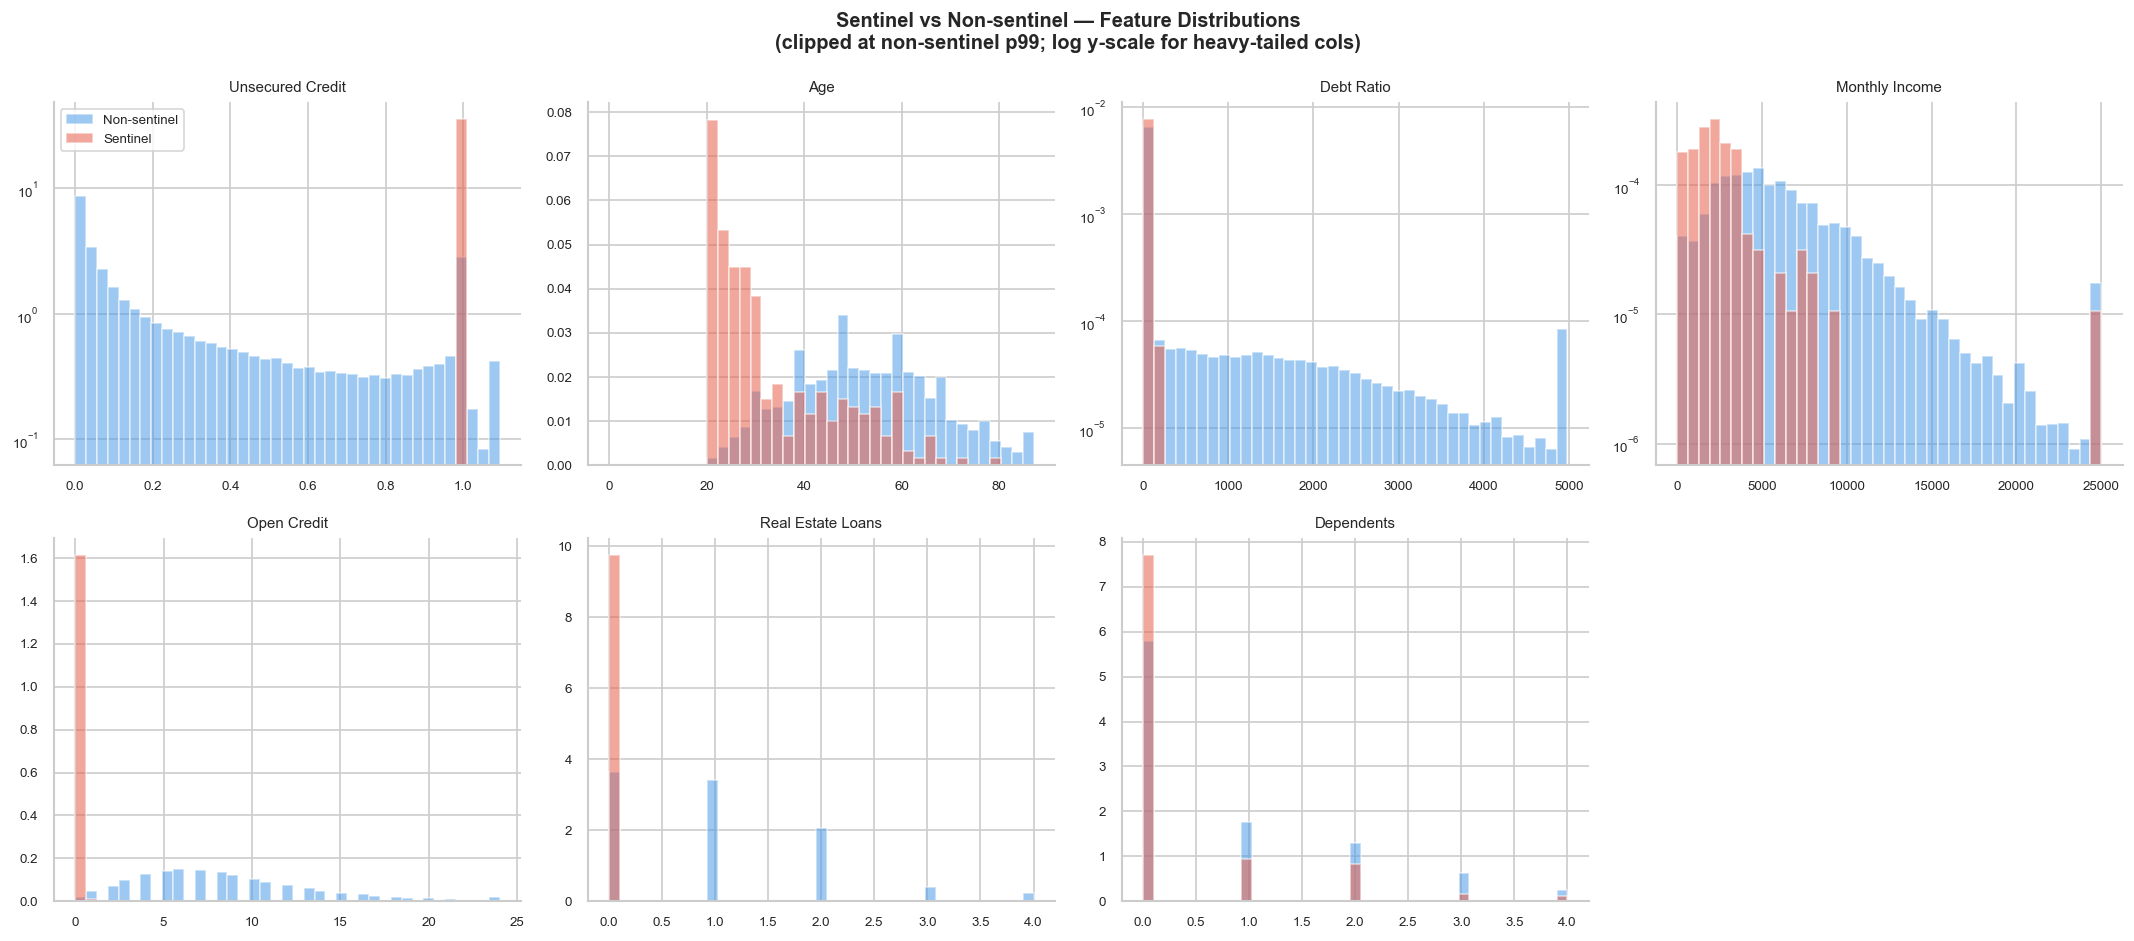

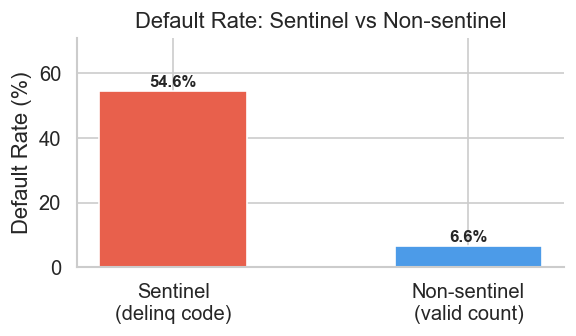

In [6]:
PLOT_COLS = ['unsecured_credit', 'age', 'debt_ratio', 'monthly_income',
             'open_credit', 'real_estate_loans', 'dependents']
LOG_COLS  = {'unsecured_credit', 'debt_ratio', 'monthly_income'}

ncols = 4
nrows = (len(PLOT_COLS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

SENT_CLR = '#E8604C'
NS_CLR   = '#4C9BE8'

for i, col in enumerate(PLOT_COLS):
    ax = axes[i]
    s_data  = sentinel[col].dropna()
    ns_data = non_sent[col].dropna()

    p99  = ns_data.quantile(0.99)
    bins = np.linspace(0, p99, 40)

    ax.hist(ns_data.clip(upper=p99), bins=bins, density=True,
            alpha=0.55, color=NS_CLR,   label='Non-sentinel')
    ax.hist(s_data.clip(upper=p99),  bins=bins, density=True,
            alpha=0.55, color=SENT_CLR, label='Sentinel')

    if col in LOG_COLS:
        ax.set_yscale('log')

    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Sentinel vs Non-sentinel — Feature Distributions\n'
             '(clipped at non-sentinel p99; log y-scale for heavy-tailed cols)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Default-rate bar ───────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(5, 3))
groups = ['Sentinel\n(delinq code)', 'Non-sentinel\n(valid count)']
rates  = [sentinel['defaulted'].mean() * 100, non_sent['defaulted'].mean() * 100]
colors = [SENT_CLR, NS_CLR]
bars = ax2.bar(groups, rates, color=colors, width=0.5, edgecolor='white')
for bar, rate in zip(bars, rates):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Default Rate (%)')
ax2.set_title('Default Rate: Sentinel vs Non-sentinel')
ax2.set_ylim(0, max(rates) * 1.3)
plt.tight_layout()
plt.show()

---
## 4 · Missingness Analysis

### Theory

Missing data is rarely random. Understanding **why** data is missing is as important as knowing **how much** is missing.  
Rubin (1976) classifies missing data into three mechanisms:

| Mechanism | Acronym | Meaning |
|---|---|---|
| Missing Completely At Random | **MCAR** | Missingness is unrelated to any data, observed or unobserved. Safe to drop rows. |
| Missing At Random | **MAR** | Missingness depends only on *observed* variables. Imputation conditioned on observed covariates is valid. |
| Missing Not At Random | **MNAR** | Missingness depends on the *unobserved* value itself (e.g. high earners less likely to report income). Most dangerous — imputation can bias results. |

**In credit scoring**, `MonthlyIncome` is often MNAR: high-income individuals may omit income fields on applications. The appropriate strategy depends on the mechanism and the predictive importance of the variable.

In [7]:
# ── missing value summary table ──────────────────────────────────────────────
miss = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     df.isnull().mean() * 100,
    'Dtype':         df.dtypes,
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

miss.style \
    .format({'Missing Count': '{:,.0f}', 'Missing %': '{:.2f}%'}) \
    .background_gradient(subset=['Missing %'], cmap='Reds')

,Missing Count,Missing %,Dtype
monthly_income,"29,731",19.82%,float64
dependents,"3,924",2.62%,float64


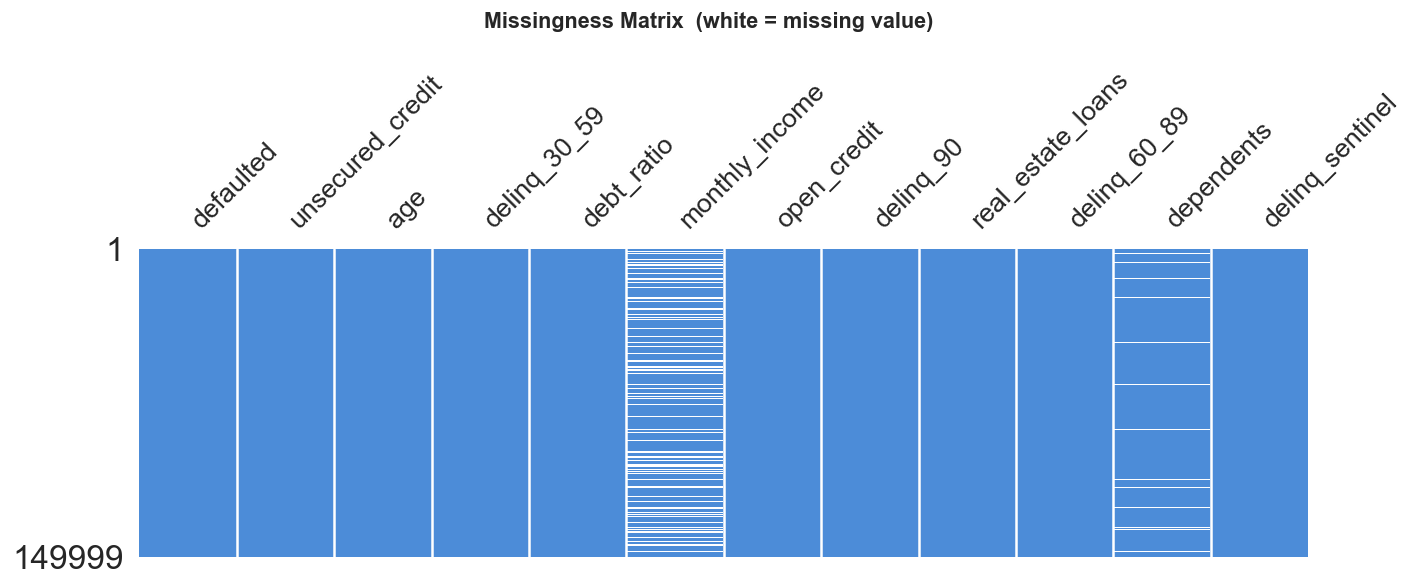

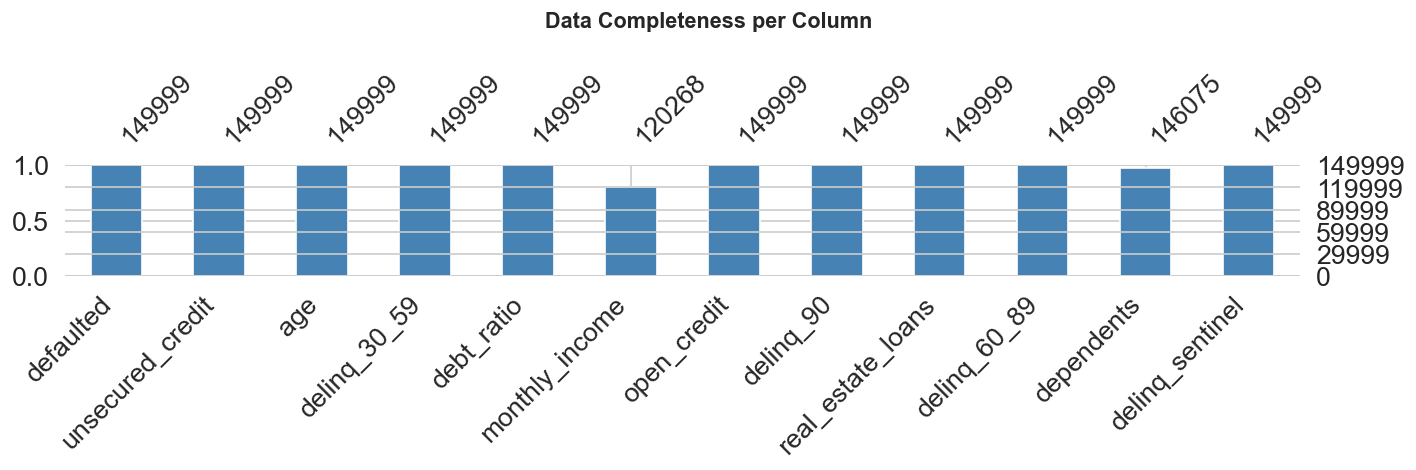

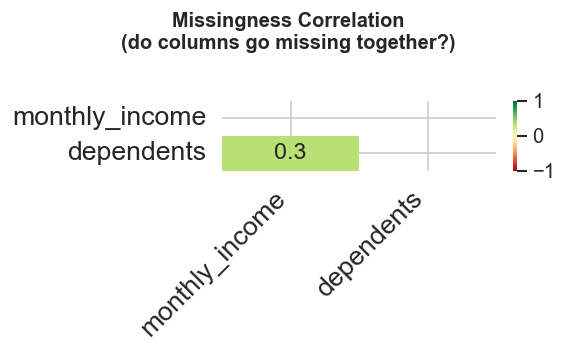

In [8]:
# ── 1. Missingness matrix — row-level patterns (white stripe = missing) ──────
msno.matrix(df, sparkline=False, color=(0.3, 0.55, 0.85), figsize=(12, 5))
plt.gcf().suptitle('Missingness Matrix  (white = missing value)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Bar chart — completeness per column ────────────────────────────────────
msno.bar(df, color='steelblue', figsize=(12, 4))
plt.gcf().suptitle('Data Completeness per Column', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 3. Heatmap — do columns go missing together? ─────────────────────────────
# Only columns with any missingness appear; here: monthly_income & dependents.
# A positive correlation (~0.3) means they tend to be missing on the same rows.
msno.heatmap(df, cmap='RdYlGn', figsize=(5, 3))
plt.gcf().suptitle('Missingness Correlation\n(do columns go missing together?)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


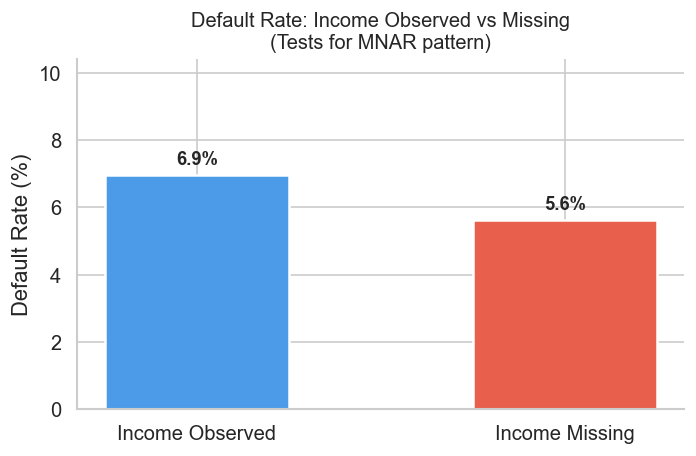

Chi-square test — χ²=67.90,  p=0.0000
→ Missingness in monthly_income is SIGNIFICANTLY associated with default status.


In [9]:
# ── is missingness in monthly_income related to default status? (MNAR test) ──
df['income_missing'] = df['monthly_income'].isnull().astype(int)

miss_default_rate = df.groupby('income_missing')['defaulted'].mean().rename({0: 'Income Observed', 1: 'Income Missing'})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(miss_default_rate.index, miss_default_rate.values * 100,
              color=[GOOD_CLR, BAD_CLR], edgecolor='white', linewidth=1.5, width=0.5)
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate: Income Observed vs Missing\n(Tests for MNAR pattern)', fontsize=12)
ax.set_ylim(0, miss_default_rate.max() * 150)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Income Observed', 'Income Missing'])
plt.tight_layout()
plt.show()

# chi-square test
ct = pd.crosstab(df['income_missing'], df['defaulted'])
chi2, p_val, _, _ = stats.chi2_contingency(ct)
print(f'Chi-square test — χ²={chi2:.2f},  p={p_val:.4f}')
print('→ Missingness in monthly_income is', 'SIGNIFICANTLY' if p_val < 0.05 else 'NOT significantly', 'associated with default status.')

df.drop(columns='income_missing', inplace=True)

### Imputation Strategy

Given the MAR/MNAR nature of the missing fields:

- **`monthly_income`** (19.8% missing): Impute with the **median** (robust to the right-skewed income distribution and high-earner outliers). A more principled approach for modelling would be multiple imputation or a regression-based imputer.
- **`dependents`** (2.6% missing): Impute with **0** — conservative assumption that unreported dependents are absent; confirmed to have low predictive importance.

In [10]:
# ── Missing indicators (before imputation) ───────────────────────────────────
# Binary flags preserve the information that a value was absent.
# These can be used as features in downstream models.
# Use raw to ensure indicators are correct regardless of re-execution order.
# Note: delinq_sentinel was already created in the cleaning cell above.
df['monthly_income_missing'] = raw.loc[df.index, 'monthly_income'].isna().astype(int)
df['dependents_missing']     = raw.loc[df.index, 'dependents'].isna().astype(int)

print('Missing indicator counts:')
print(df[['delinq_sentinel', 'monthly_income_missing', 'dependents_missing']].sum().to_string())

# ── Imputation ────────────────────────────────────────────────────────────────
median_income = df['monthly_income'].median()
df['monthly_income'] = df['monthly_income'].fillna(median_income)
df['dependents']     = df['dependents'].fillna(0)

print(f'Imputed monthly_income NAs with median: ${median_income:,.0f}')
print(f'Imputed dependents NAs with 0')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Missing indicator counts:
delinq_sentinel             269
monthly_income_missing    29731
dependents_missing         3924
Imputed monthly_income NAs with median: $5,400
Imputed dependents NAs with 0
Remaining missing values: 0


---
## 5 · Univariate Analysis

Univariate analysis examines each feature in isolation.  
Key questions:
- What is the **shape** of each distribution (normal, skewed, bimodal)?
- Are there **outliers** or impossible values remaining?
- What is the **scale** and **spread** of each variable?

For modelling, highly skewed variables often benefit from log-transformation. For EDA purposes we report them as-is and note the skew.

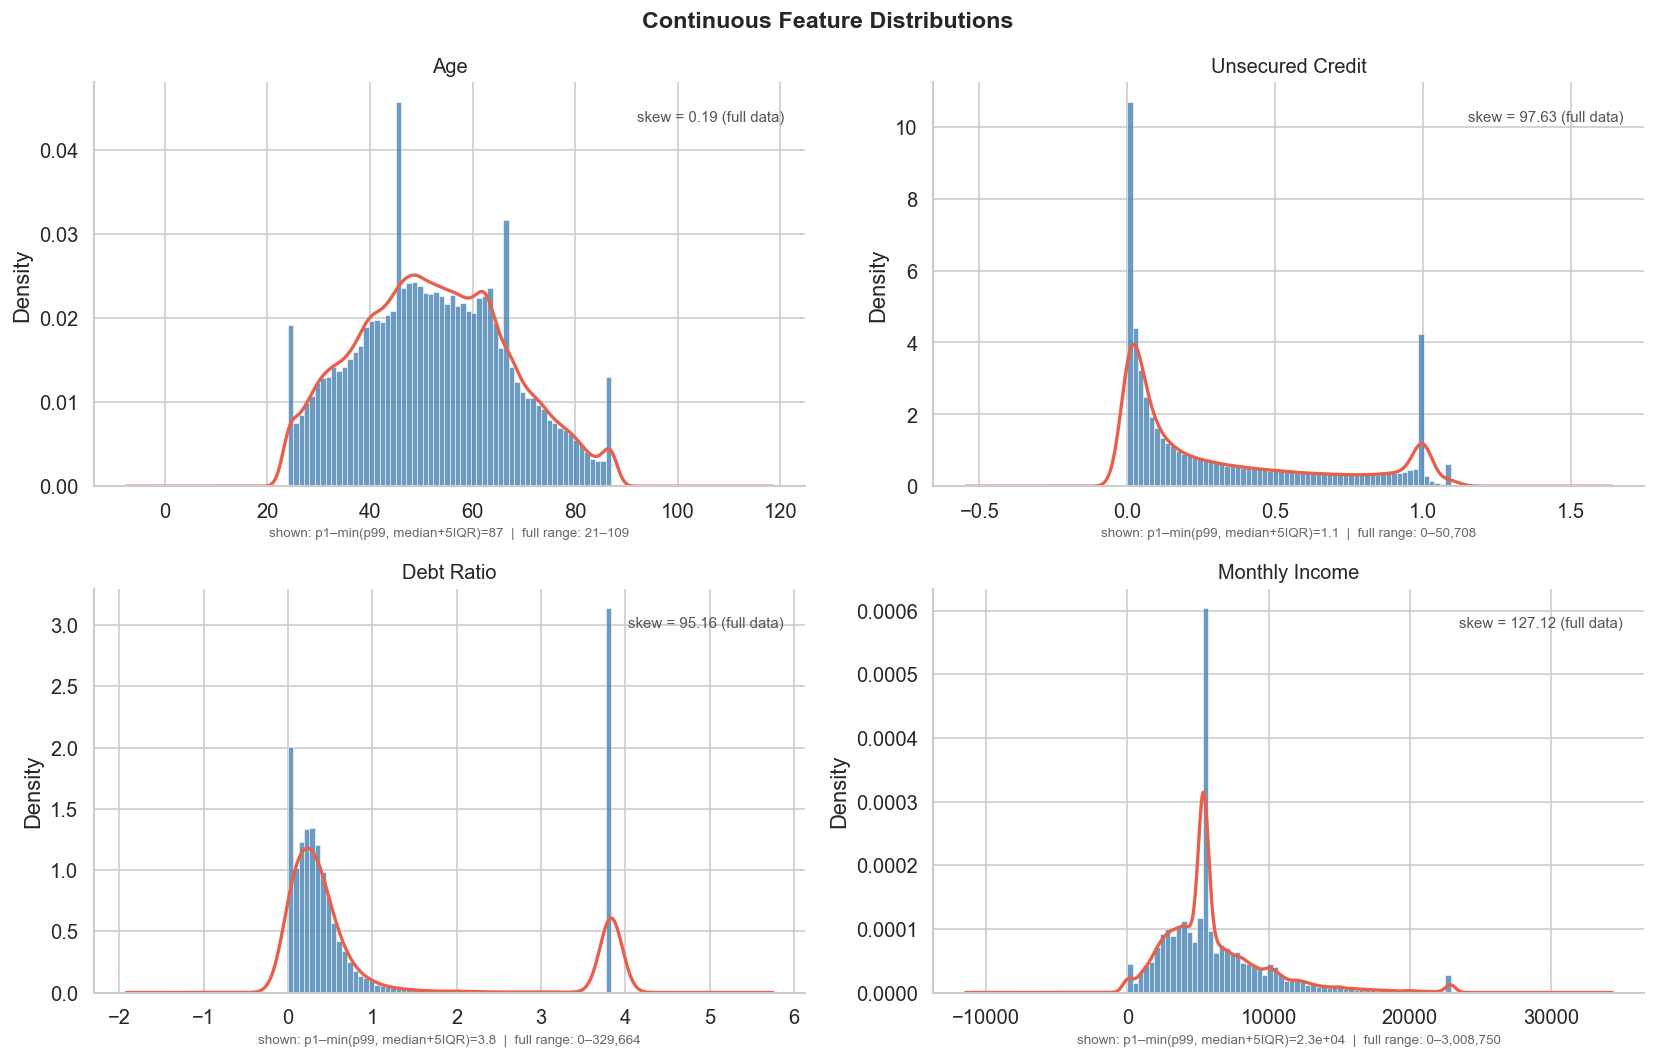

In [11]:
# continuous features
# x-axis clipped to min(p99, median + 5*IQR) so heavy-tailed features
# (e.g. debt_ratio, monthly_income) show their actual bulk distribution.
continuous = ["age", "unsecured_credit", "debt_ratio", "monthly_income"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(continuous):
    ax = axes[i]
    data = df[col].dropna()
    skew = data.skew()

    p01  = data.quantile(0.01)
    p25, p50, p75 = data.quantile(0.25), data.quantile(0.50), data.quantile(0.75)
    p99  = data.quantile(0.99)
    iqr_fence = p50 + 5 * (p75 - p25)
    hi = min(p99, iqr_fence) if iqr_fence > p50 else p99

    clipped = data.clip(p01, hi)

    ax.hist(clipped, bins=60, color="steelblue", edgecolor="white",
            linewidth=0.4, density=True, alpha=0.8)
    clipped.plot.kde(ax=ax, color="#E8604C", linewidth=2)

    ax.set_title(col.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel(
        "shown: p1–min(p99, median+5IQR)={:.2g}  |  full range: {:.2g}–{:,.0f}".format(hi, data.min(), data.max()),
        fontsize=8, color="#666"
    )
    ax.text(0.97, 0.93, "skew = {:.2f} (full data)".format(skew),
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, color="#555")

plt.suptitle("Continuous Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


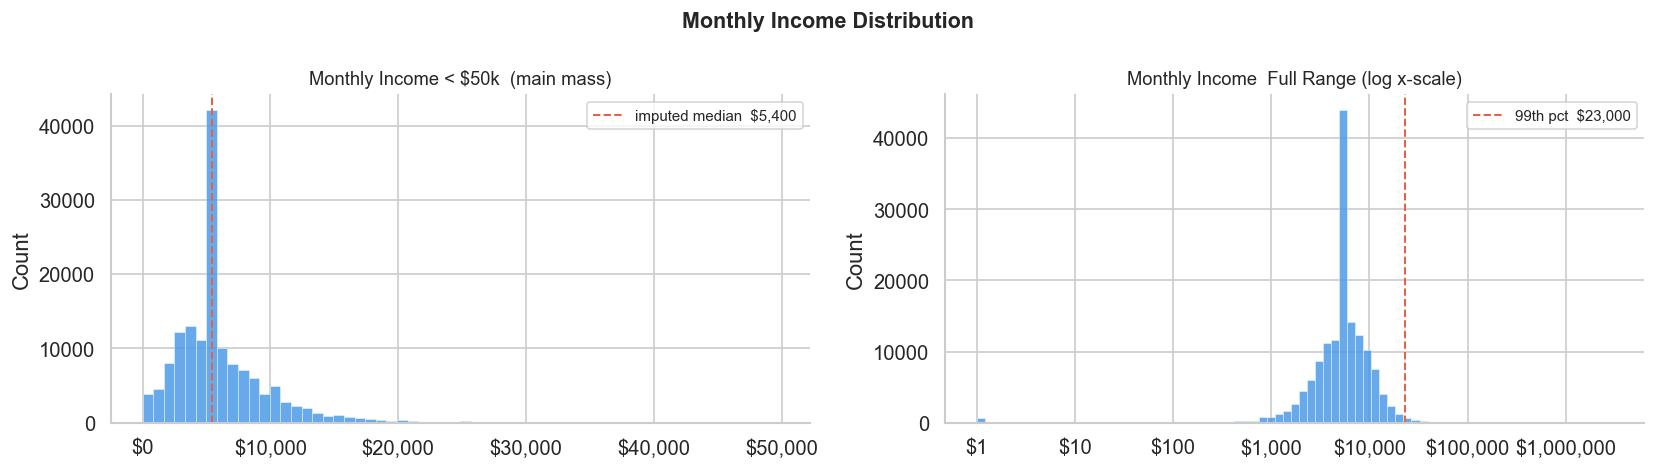

In [12]:
# monthly income: main mass + log-scale full range
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: main mass < 50k  (linear bins)
subset = df.loc[df["monthly_income"] < 50_000, "monthly_income"]
axes[0].hist(subset, bins=60, color="#4C9BE8", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(x)))
axes[0].set_title("Monthly Income < $50k  (main mass)", fontsize=11)
axes[0].set_ylabel("Count")
median_line = df["monthly_income"].median()
axes[0].axvline(median_line, color="#E8604C", linestyle="--", linewidth=1.2,
                label="imputed median  ${:,.0f}".format(int(median_line)))
axes[0].legend(fontsize=9)

# Right: full range with log-spaced bins so each decade gets equal resolution
pos = df.loc[df["monthly_income"] > 0, "monthly_income"]
log_bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 80)
axes[1].hist(pos, bins=log_bins, color="#4C9BE8", edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1].set_xscale("log")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "${:,.0f}".format(int(x))))
axes[1].set_title("Monthly Income  Full Range (log x-scale)", fontsize=11)
axes[1].set_ylabel("Count")
p99 = df["monthly_income"].quantile(0.99)
axes[1].axvline(p99, color="#E8604C", linestyle="--", linewidth=1.2,
                label="99th pct  ${:,.0f}".format(int(p99)))
axes[1].legend(fontsize=9)

plt.suptitle("Monthly Income Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


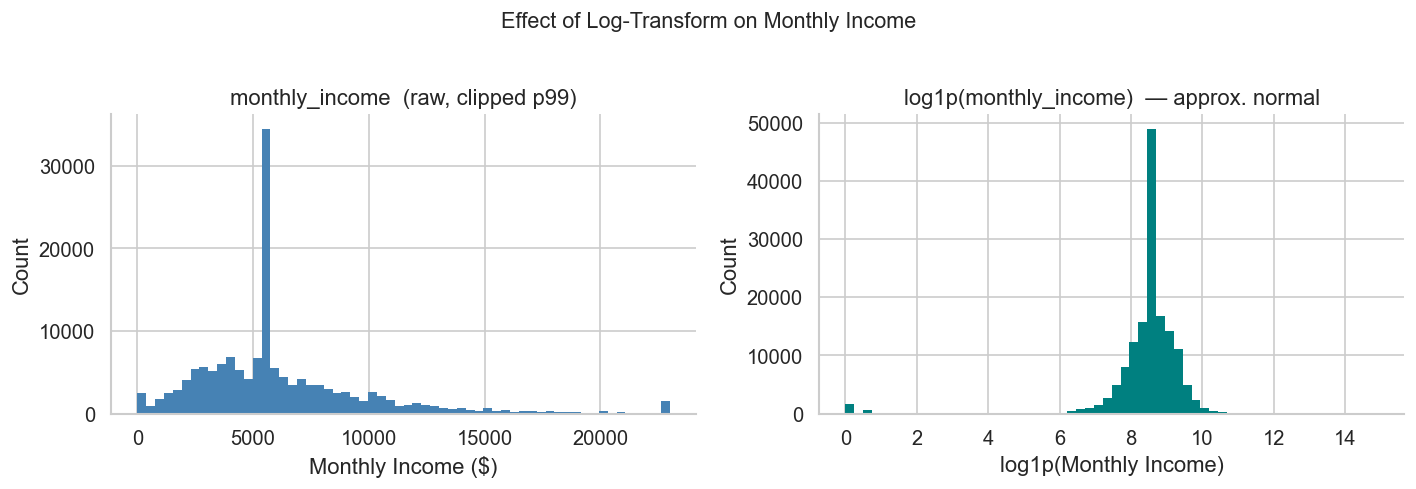

Raw skewness   : 127.12
Log1p skewness : -4.94


In [13]:
# ── Log-transform of monthly_income ───────────────────────────────────────────
# Right-skew makes linear models assume a much wider income range than reality.
# log1p(x) = log(1+x) handles the small number of zero-income rows gracefully.

log_income = np.log1p(df['monthly_income'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['monthly_income'].clip(upper=df['monthly_income'].quantile(0.99)),
             bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('monthly_income  (raw, clipped p99)')
axes[0].set_xlabel('Monthly Income ($)')

axes[1].hist(log_income, bins=60, color='teal', edgecolor='none')
axes[1].set_title('log1p(monthly_income)  — approx. normal')
axes[1].set_xlabel('log1p(Monthly Income)')

for ax in axes:
    ax.set_ylabel('Count')

plt.suptitle('Effect of Log-Transform on Monthly Income', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Raw skewness   : {df['monthly_income'].skew():.2f}")
print(f"Log1p skewness : {log_income.skew():.2f}")

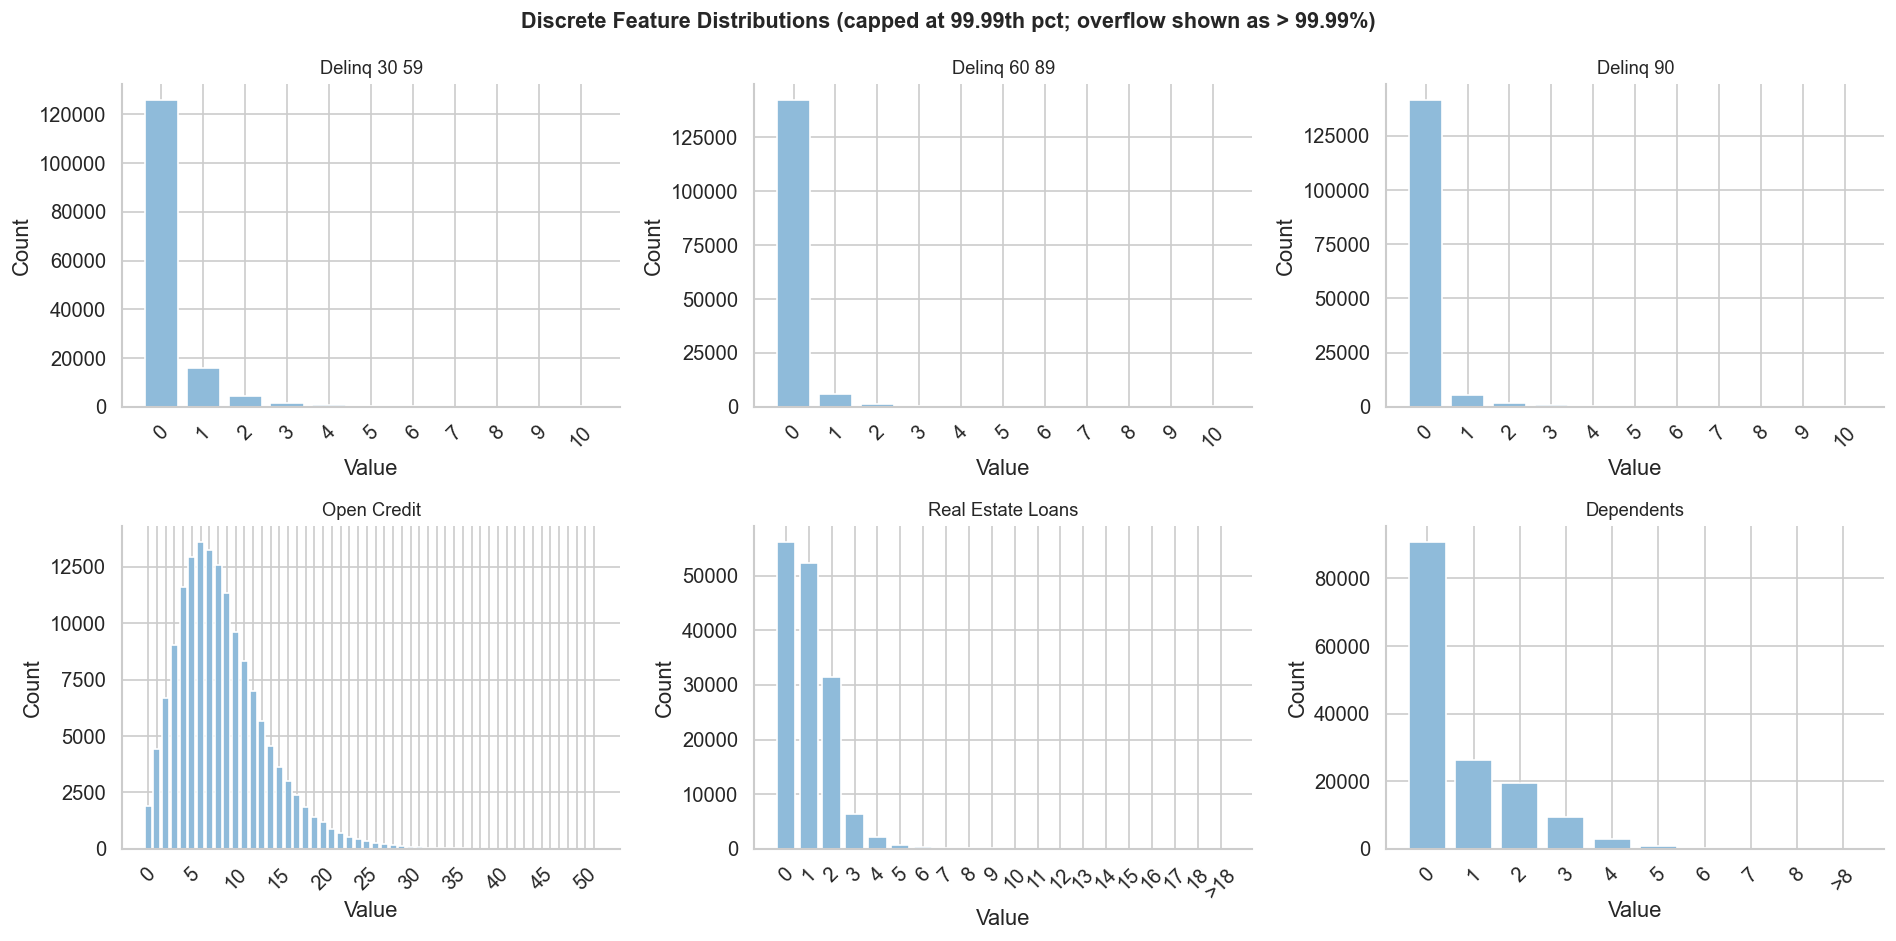

In [14]:
# ── discrete / count features ────────────────────────────────────────────────
discrete = ['delinq_30_59', 'delinq_60_89', 'delinq_90',
            'open_credit', 'real_estate_loans', 'dependents']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(discrete):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    # cap at 99.99th percentile for readability
    cap = df[col].quantile(0.9999)
    shown   = counts[counts.index <= cap]
    overflow = counts[counts.index > cap].sum()
    # clean labels: convert float indices like 0.0 → "0"
    labels = [str(int(v)) if v == int(v) else str(v) for v in shown.index]
    values = list(shown.values)
    if overflow > 0:
        labels.append(f'>{cap:.0f}')
        values.append(overflow)
    ax.bar(labels, values, color='#8fbbda', edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    # thin out x-axis labels for crowded plots (show every 5th)
    if col == 'open_credit':
        ticks = ax.get_xticks()
        tick_labels = [t.get_text() for t in ax.get_xticklabels()]
        ax.set_xticks(ticks)
        ax.set_xticklabels([l if j % 5 == 0 else '' for j, l in enumerate(tick_labels)])

plt.suptitle('Discrete Feature Distributions (capped at 99.99th pct; overflow shown as > 99.99%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

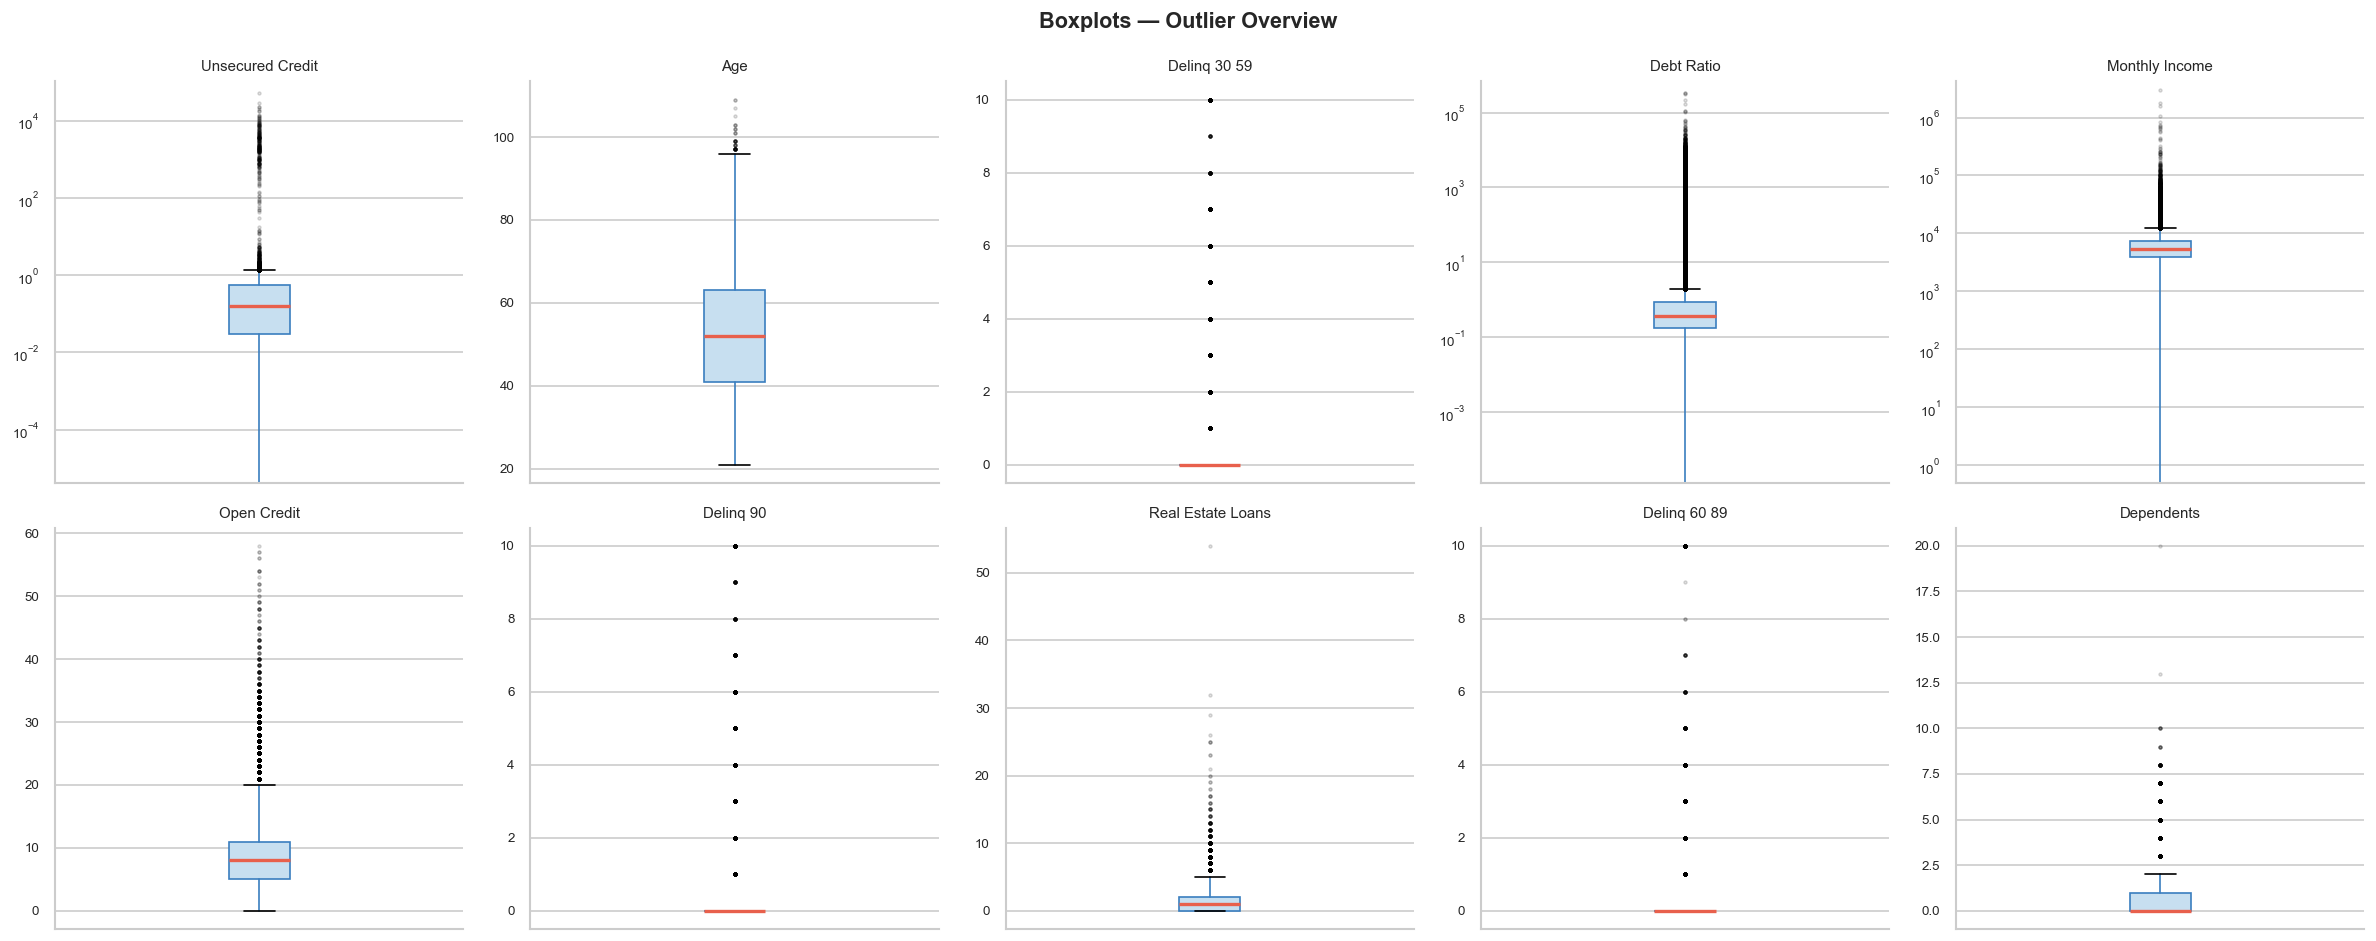

In [15]:
# Boxplots — log y-scale only for the three heavy-tailed continuous columns;
# count/discrete columns (delinq_*, open_credit, dependents) use linear scale.
LOG_SCALE_COLS = {"unsecured_credit", "debt_ratio", "monthly_income"}
INDICATOR_COLS = {"defaulted", "monthly_income_missing", "dependents_missing", "delinq_sentinel"}
num_cols = [c for c in df.columns if c not in INDICATOR_COLS]

ncols = 5
nrows = (len(num_cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#c7dff0", color="#3a7ebf"),
               medianprops=dict(color="#E8604C", linewidth=2),
               whiskerprops=dict(color="#3a7ebf"),
               flierprops=dict(marker=".", color="#E8604C", alpha=0.2, markersize=3))
    if col in LOG_SCALE_COLS:
        pos_min = data[data > 0].min() if (data > 0).any() else 1e-3
        ax.set_yscale("log")
        ax.set_ylim(bottom=pos_min * 0.5)
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xticks([])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — Outlier Overview", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6 · Target Variable & Class Imbalance

### Theory

**Class imbalance** is a fundamental challenge in credit risk modelling.  
Real-world default rates are typically between 2 – 10%, meaning the dataset is highly skewed towards non-defaults.

Naive classifiers that simply predict 0 for everyone would achieve ~93% accuracy but provide zero value.  
Addressing imbalance is critical for building useful models. Common strategies include:

| Technique | Idea |
|---|---|
| **Over-sampling** (e.g. SMOTE) | Synthetically generate minority class samples |
| **Under-sampling** | Reduce majority class samples |
| **Cost-sensitive learning** | Penalise misclassification of the minority class more heavily |
| **Threshold tuning** | Choose a decision threshold that balances precision/recall for business needs |

The appropriate strategy depends on the **cost asymmetry**: in lending, a missed default (false negative) is usually far more costly than a declined good customer (false positive).

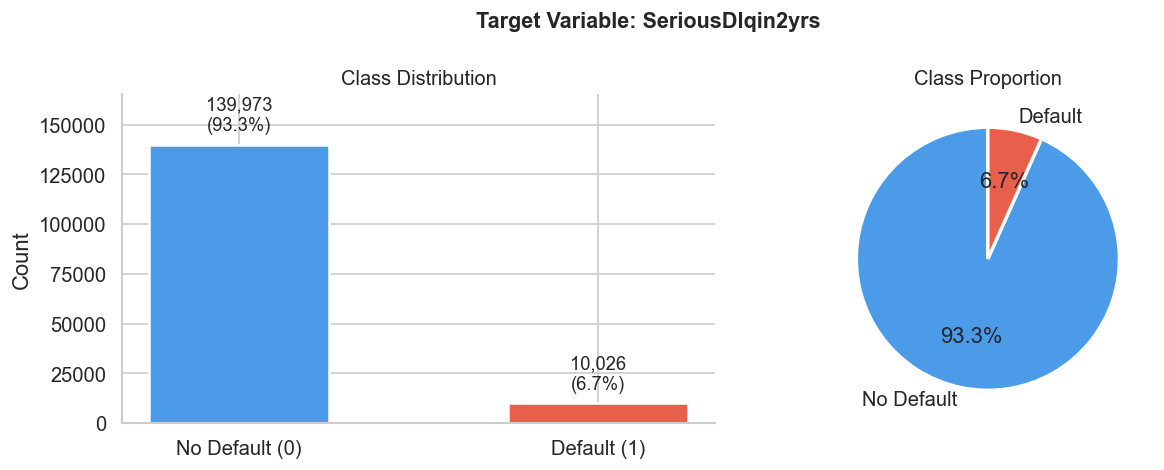

Imbalance ratio (non-default : default) = 14.0 : 1


In [16]:
target_counts = df['defaulted'].value_counts().sort_index()
target_pct    = (target_counts / len(df) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# bar chart
bars = axes[0].bar(['No Default (0)', 'Default (1)'],
                   target_counts.values,
                   color=[GOOD_CLR, BAD_CLR], edgecolor='white', linewidth=1.5, width=0.5)
axes[0].bar_label(bars,
                  labels=[f'{v:,}\n({p:.1f}%)' for v, p in zip(target_counts.values, target_pct.values)],
                  padding=6, fontsize=11)
axes[0].set_title('Class Distribution', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, target_counts.max() * 1.18)

# pie chart
axes[1].pie(target_counts.values,
            labels=['No Default', 'Default'],
            colors=[GOOD_CLR, BAD_CLR],
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion', fontsize=12)

plt.suptitle('Target Variable: SeriousDlqin2yrs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ir = target_counts[0] / target_counts[1]
print(f'Imbalance ratio (non-default : default) = {ir:.1f} : 1')

---
## 7 · Bivariate Analysis

Bivariate analysis examines the relationship between **each feature and the target**.  
This surfaces which variables are the most discriminating — i.e. which features shift meaningfully between the default and non-default groups.

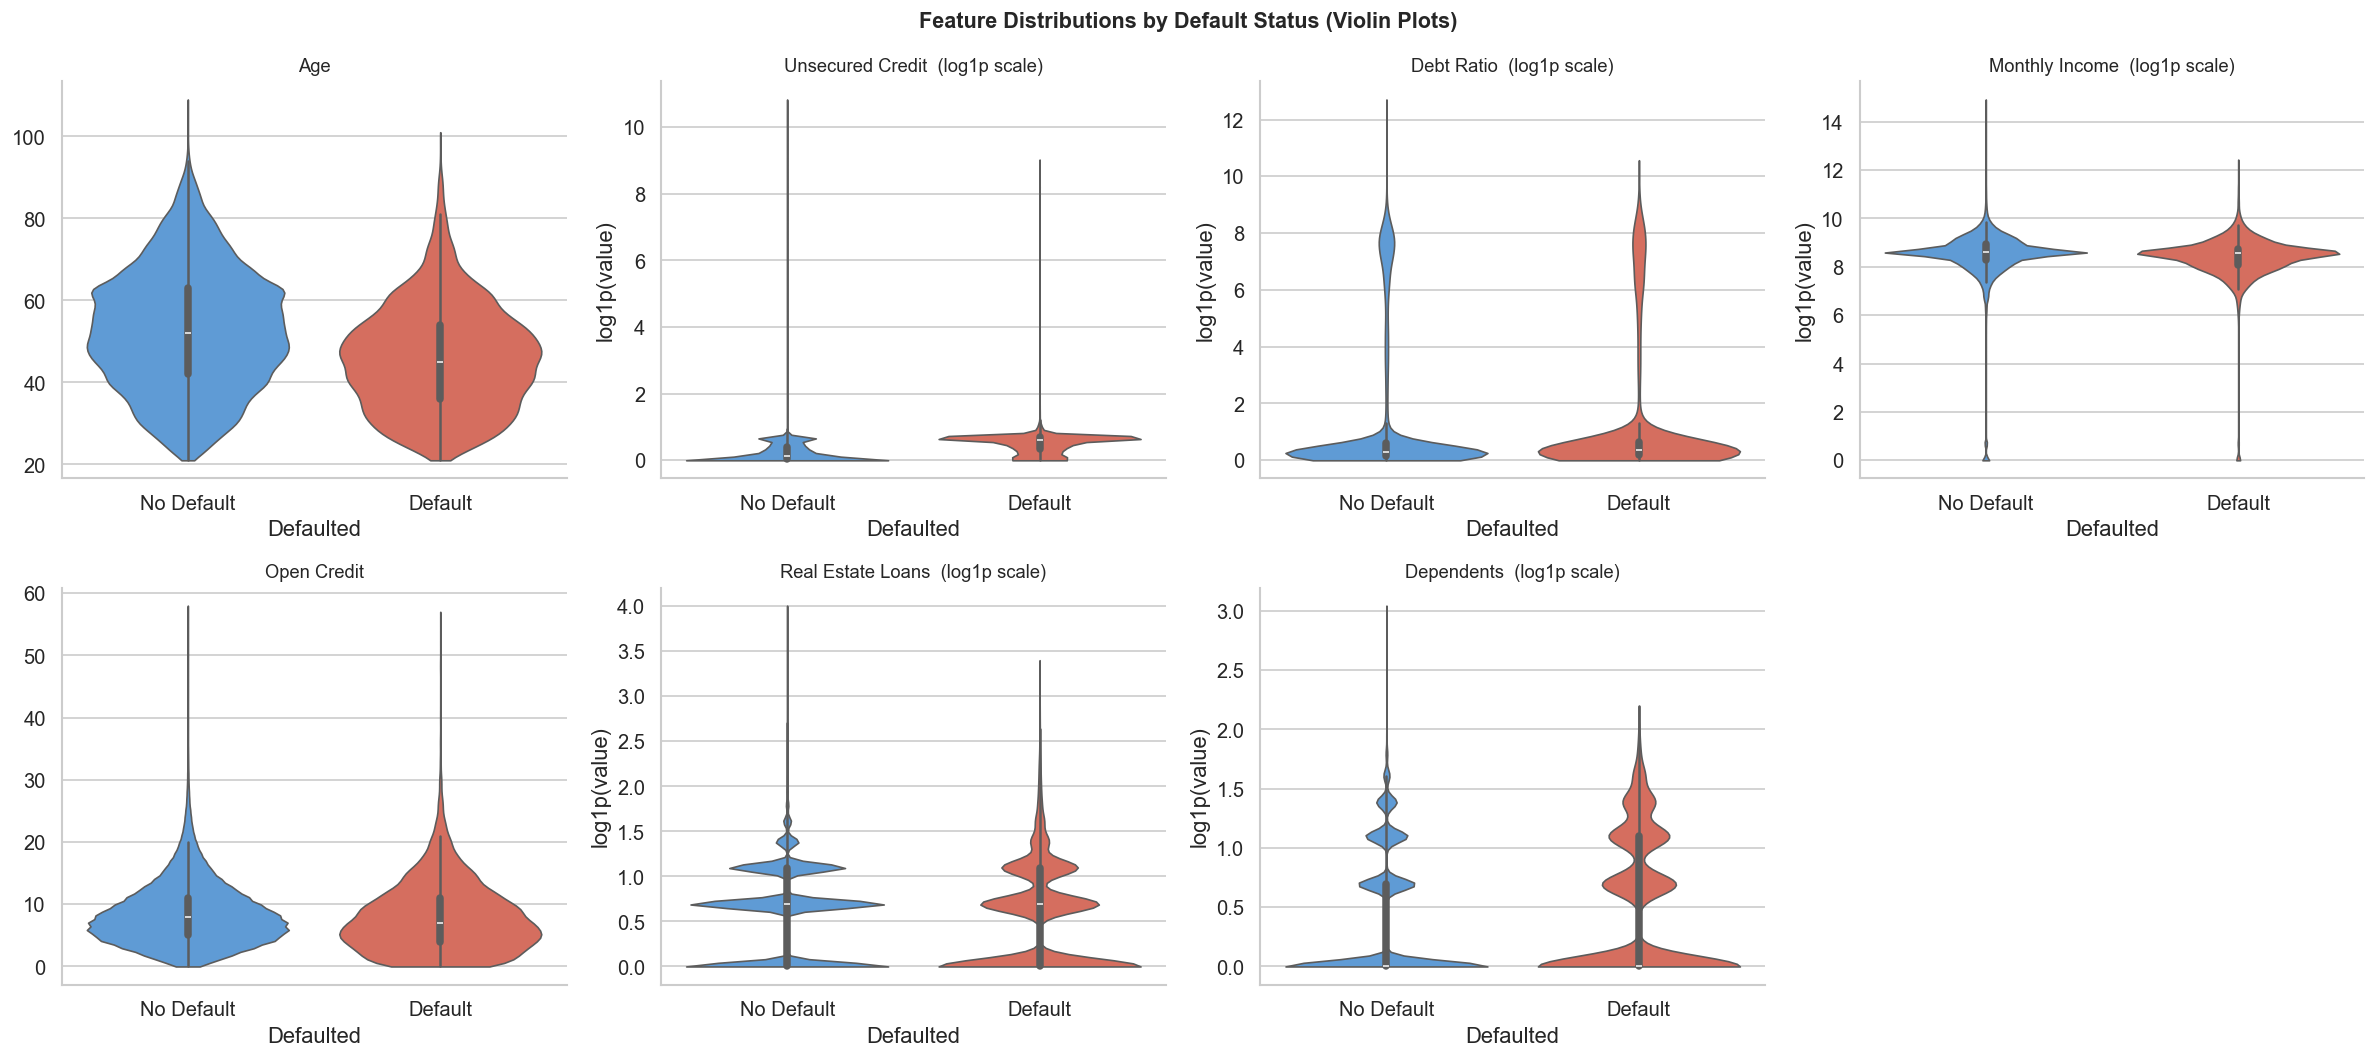

In [17]:
# ── violin + box overlaid per feature, split by target ───────────────────────
features = ['age', 'unsecured_credit', 'debt_ratio', 'monthly_income',
            'open_credit', 'real_estate_loans', 'dependents']

LOG_VIOLIN_COLS = {'unsecured_credit', 'debt_ratio', 'monthly_income',
                   'real_estate_loans', 'dependents'}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]

    plot_df = df[['defaulted', col]].copy()
    if col in LOG_VIOLIN_COLS:
        # shift by small epsilon so log scale works for zero values
        plot_df[col] = np.log1p(plot_df[col])

    sns.violinplot(data=plot_df, x='defaulted', y=col, ax=ax,
                   palette=[GOOD_CLR, BAD_CLR], inner='box', hue='defaulted', legend=False,
                   cut=0, linewidth=1)

    title = col.replace('_', ' ').title()
    if col in LOG_VIOLIN_COLS:
        title += '  (log1p scale)'
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Defaulted')
    ax.set_ylabel('log1p(value)' if col in LOG_VIOLIN_COLS else '')
    ax.set_xticklabels(['No Default', 'Default'])

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Default Status (Violin Plots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

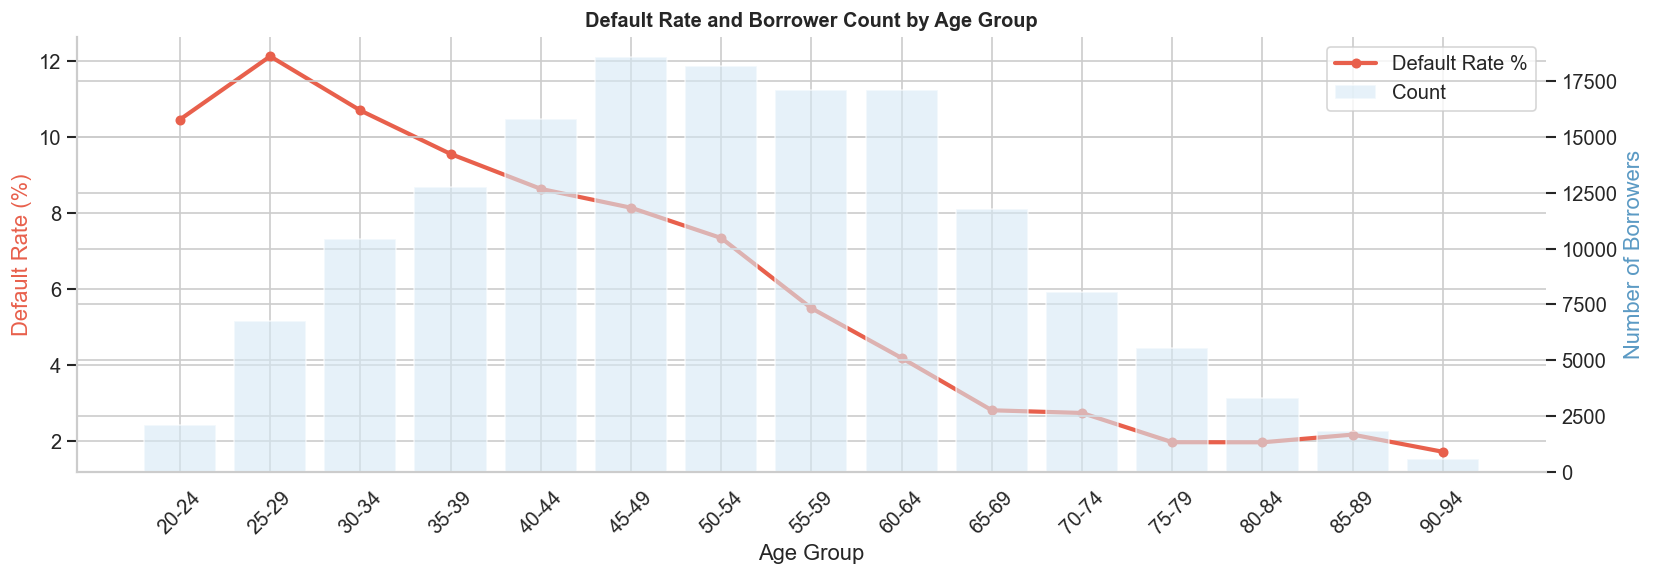

In [18]:
# ── default rate by age group ────────────────────────────────────────────────
df['age_group'] = pd.cut(df['age'], bins=range(20, 100, 5),
                          right=False,
                          labels=[f'{a}-{a+4}' for a in range(20, 95, 5)])

age_default = df.groupby('age_group', observed=True)['defaulted'].agg(['mean', 'count']).reset_index()
age_default['default_rate'] = age_default['mean'] * 100

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax2.bar(age_default['age_group'].astype(str), age_default['count'],
        color='#d6e9f5', alpha=0.6, label='Count')
ax1.plot(age_default['age_group'].astype(str), age_default['default_rate'],
         color=BAD_CLR, marker='o', linewidth=2.5, markersize=5, label='Default Rate %', zorder=5)

ax1.set_ylabel('Default Rate (%)', color=BAD_CLR)
ax2.set_ylabel('Number of Borrowers', color='#5b9ac4')
ax1.set_xlabel('Age Group')
ax1.tick_params(axis='x', rotation=45)
ax1.set_title('Default Rate and Borrower Count by Age Group', fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

df.drop(columns='age_group', inplace=True)

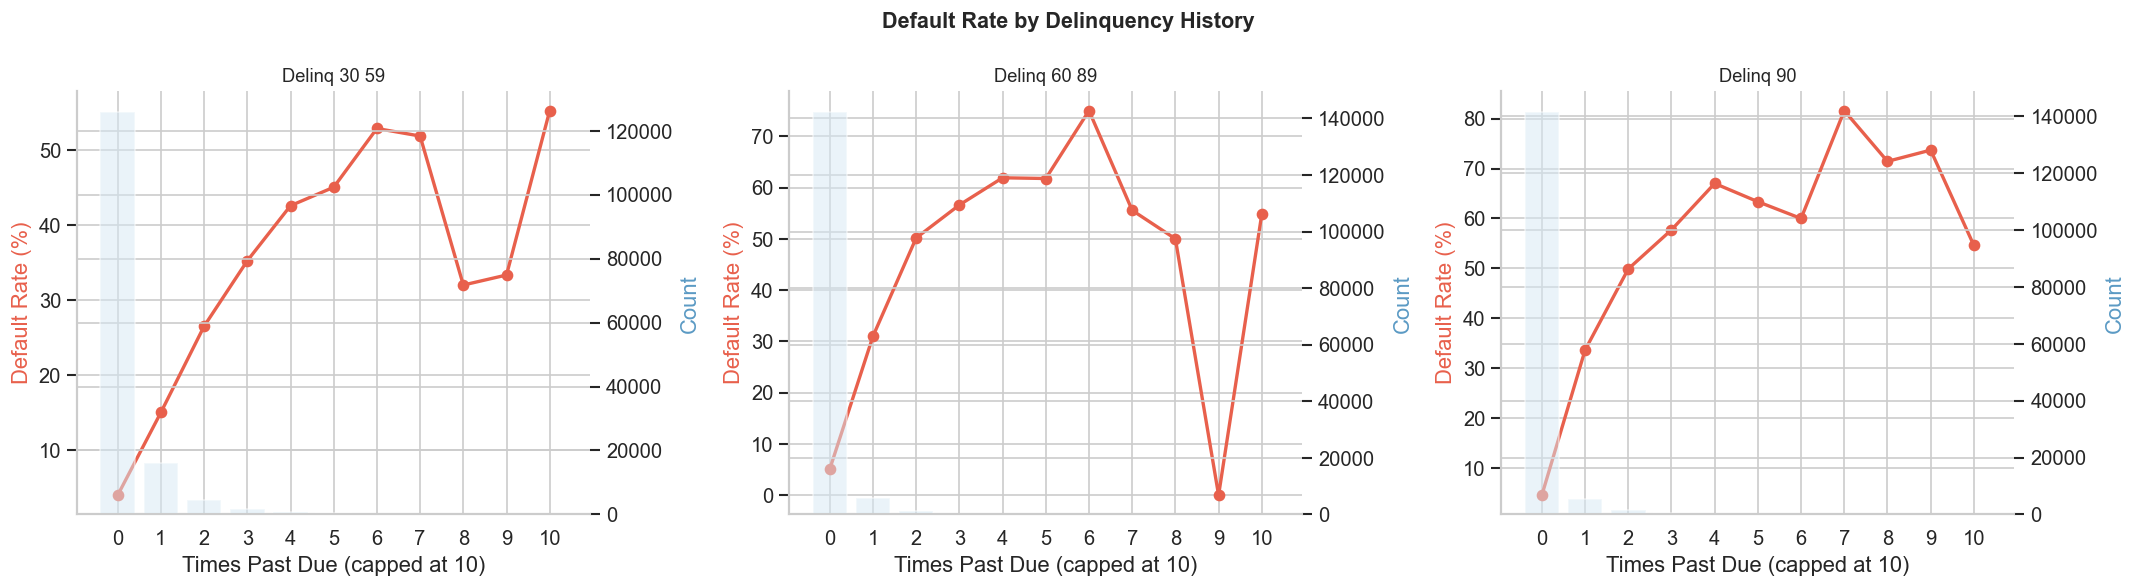

In [19]:
# ── default rate by delinquency variables ────────────────────────────────────
delinq_cols = ['delinq_30_59', 'delinq_60_89', 'delinq_90']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, delinq_cols):
    rates  = df.groupby(col)['defaulted'].mean() * 100
    counts = df.groupby(col)['defaulted'].count()

    ax2 = ax.twinx()
    ax2.bar(rates.index.astype(str), counts.values, color='#d6e9f5', alpha=0.5)
    ax.plot(rates.index.astype(str), rates.values,
            color=BAD_CLR, marker='o', linewidth=2, zorder=5)
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.set_xlabel('Times Past Due (capped at 10)')
    ax.set_ylabel('Default Rate (%)', color=BAD_CLR)
    ax2.set_ylabel('Count', color='#5b9ac4')

plt.suptitle('Default Rate by Delinquency History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ── mean feature values: defaulted vs non-defaulted ──────────────────────────
feat_cols = [c for c in df.columns if c != 'defaulted']
means = df.groupby('defaulted')[feat_cols].mean().T
means.columns = ['Non-Default (0)', 'Default (1)']
means['Ratio (Default/Non-Default)'] = means['Default (1)'] / means['Non-Default (0)']
means.style \
    .format('{:.3f}') \
    .background_gradient(subset=['Ratio (Default/Non-Default)'], cmap='RdYlGn_r')

,Non-Default (0),Default (1),Ratio (Default/Non-Default)
unsecured_credit,6.169,4.367,0.708
age,52.752,45.927,0.871
delinq_30_59,0.203,1.098,5.400
debt_ratio,357.154,295.121,0.826
monthly_income,6477.627,5592.401,0.863
open_credit,8.494,7.882,0.928
delinq_90,0.058,0.800,13.701
real_estate_loans,1.020,0.989,0.969
delinq_60_89,0.050,0.538,10.774
dependents,0.724,0.931,1.287


---

## 8 · Correlation Analysis

### Theory

Correlation analysis quantifies the **linear (Pearson)** or **monotonic (Spearman)** relationship between pairs of variables.  
Values range from **-1** (perfect inverse relationship) to **+1** (perfect positive relationship), with **0** indicating no linear association.

**Pearson correlation**:  
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}}$$

Assumes normality and is sensitive to outliers.

**Spearman rank correlation**:  
$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2 - 1)}$$

where $d_i$ is the rank difference. Non-parametric; robust to outliers and skewed distributions — better suited to this dataset.

In credit risk, high inter-feature correlation signals **multicollinearity**, which can inflate variance in logistic regression coefficients. Features that correlate strongly with the target (`defaulted`) are the most useful predictors.

> **Caveat — binary target**: Pearson/Spearman with a `{0,1}` target are mathematically valid but were designed for two *continuous* variables. They ignore the binary distributional structure and can understate non-linear or threshold effects.  
> Sections **8.1 – 8.3** below provide purpose-built measures for both continuous–binary and discrete/categorical–binary relationships, plus multiple-testing correction.

**Section structure**
| Sub-section | Inputs | Methods |
|---|---|---|
| 8.1 | Continuous × `defaulted` | Point-biserial r · Mann-Whitney U · Rank-biserial r · Cohen d · Single-feature AUC |
| 8.2 | Discrete/binary × `defaulted` | Chi-square · Cramér's V · Odds Ratio · Spearman ρ |
| 8.3 | All p-values combined | Benjamini-Hochberg FDR correction · ranked effect-size chart |


## 6 · Correlation Analysis

Pearson (linear) and Spearman (monotonic / rank) association between features and the
target. Spearman is more appropriate for the heavy-tailed and count features here. The
ranked bar chart defines `target_corr`, reused by the pairplot and the MI comparison below.

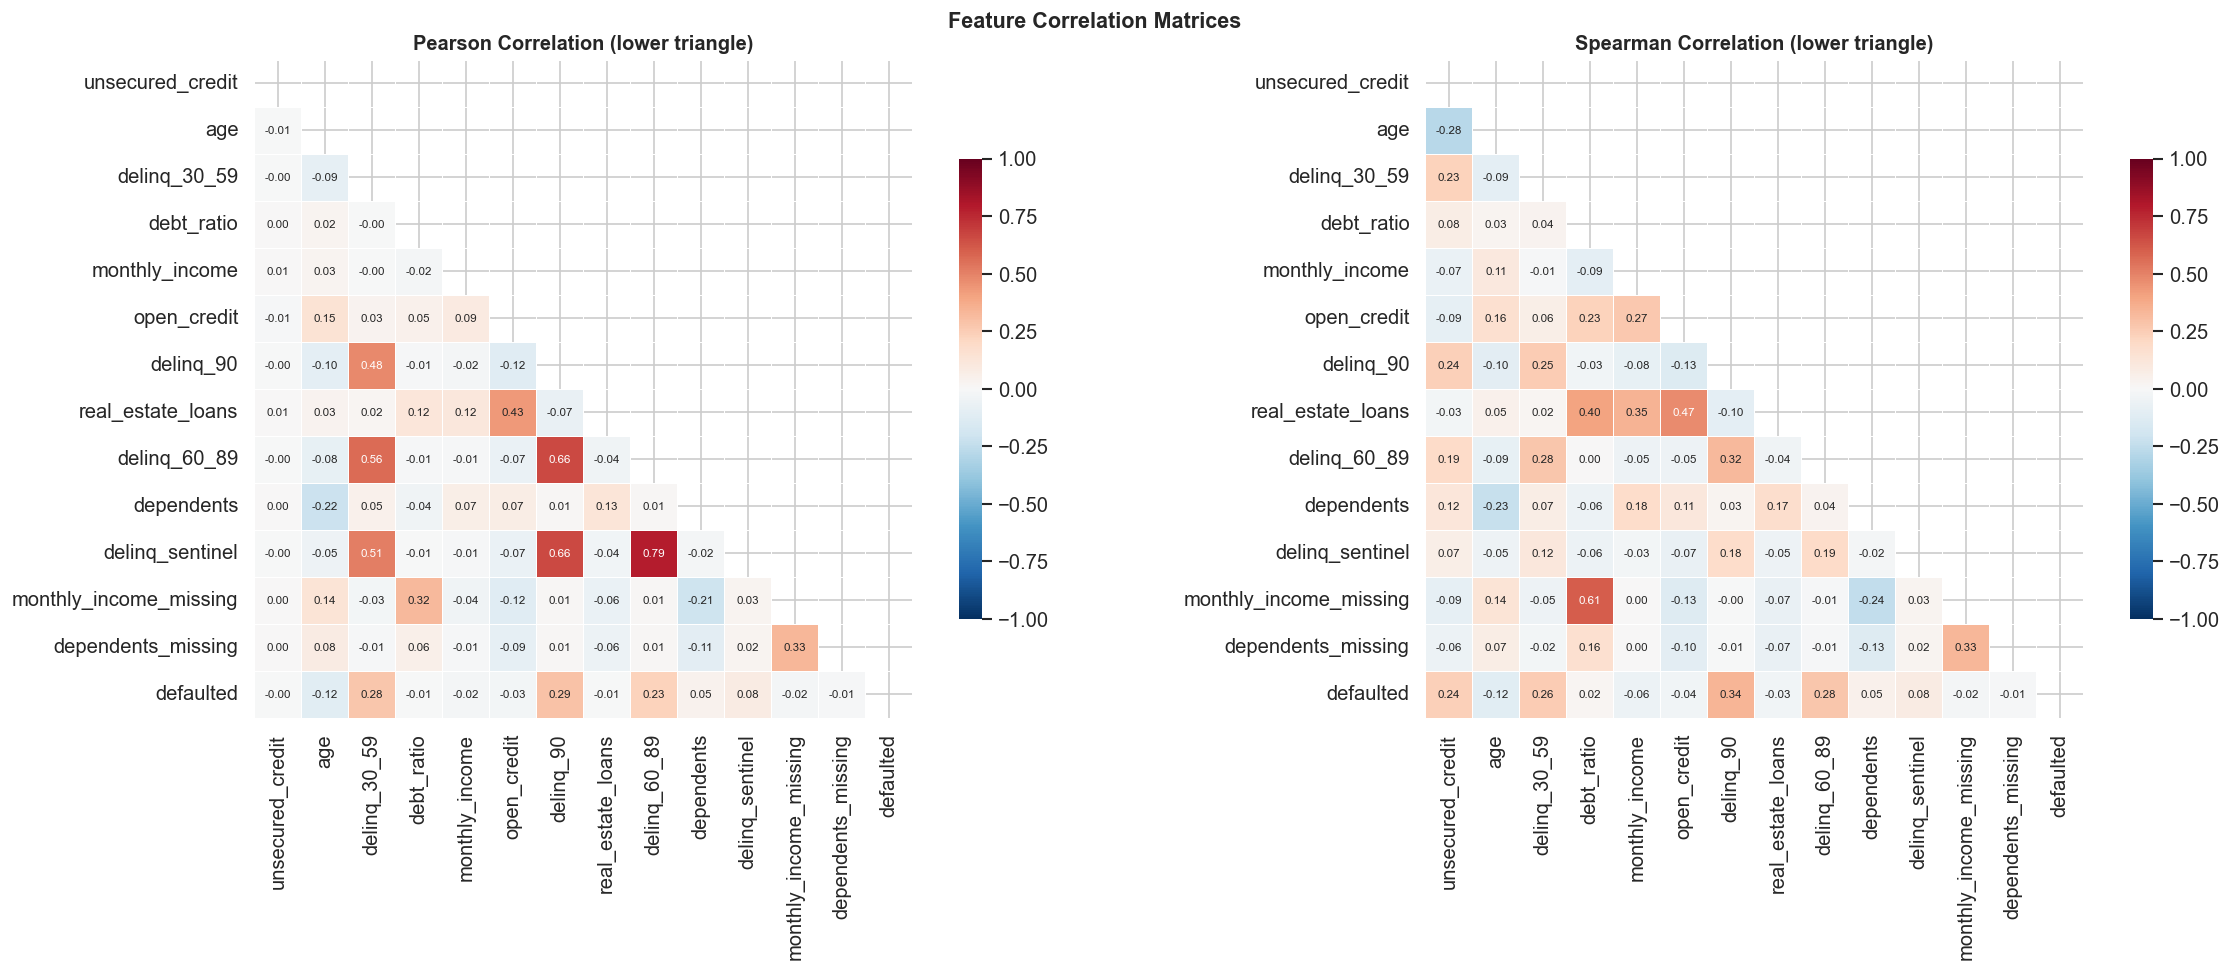

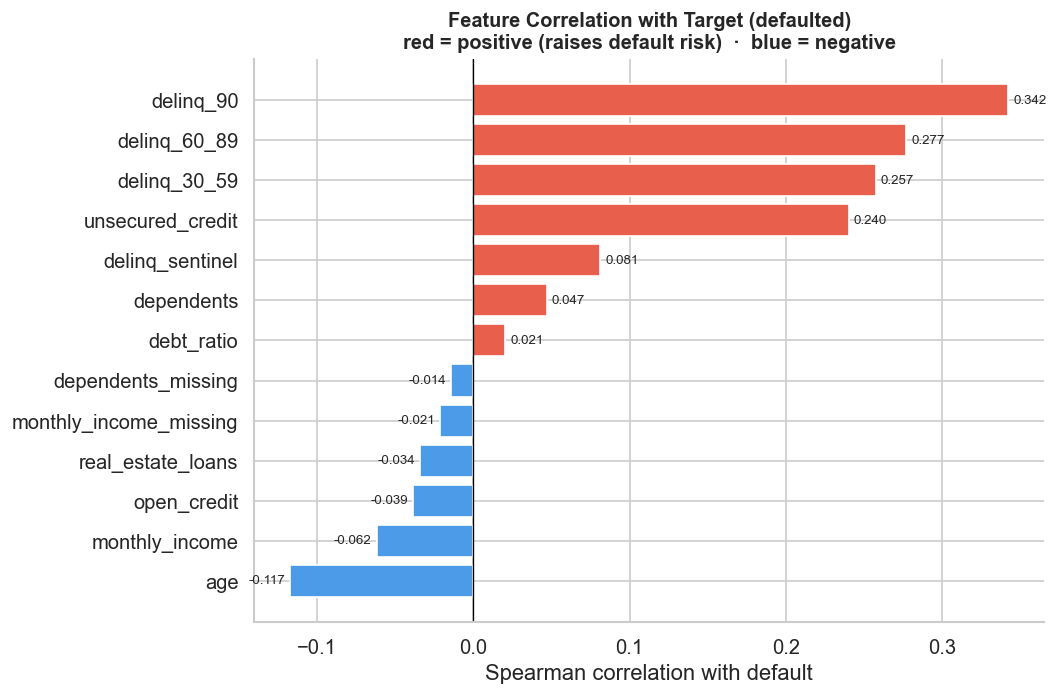

Top features by |Spearman correlation| with target:
delinq_90           0.342349
delinq_60_89        0.277111
delinq_30_59        0.257419
unsecured_credit    0.240382
age                 0.117038
delinq_sentinel     0.081401
monthly_income      0.061696
dependents          0.046908


In [21]:
# ── Pearson & Spearman correlation matrices ───────────────────────────
CORR_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio', 'monthly_income',
    'open_credit', 'delinq_90', 'real_estate_loans', 'delinq_60_89', 'dependents',
    'delinq_sentinel', 'monthly_income_missing', 'dependents_missing', 'defaulted',
]
corr_data     = df[CORR_COLS]
pearson_corr  = corr_data.corr(method='pearson')
spearman_corr = corr_data.corr(method='spearman')

# ── Side-by-side heatmaps (lower triangle only) ─────────────────────
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, mat, name in [(axes[0], pearson_corr, 'Pearson'),
                      (axes[1], spearman_corr, 'Spearman')]:
    sns.heatmap(mat, mask=mask, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 7},
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
    ax.set_title(f'{name} Correlation (lower triangle)', fontsize=12, fontweight='bold')
plt.suptitle('Feature Correlation Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Ranked correlation with the target (Spearman) ───────────────────
target_corr = spearman_corr['defaulted'].drop('defaulted').sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [BAD_CLR if v > 0 else GOOD_CLR for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Spearman correlation with default')
ax.set_title('Feature Correlation with Target (defaulted)\n'
             'red = positive (raises default risk)  ·  blue = negative',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features by |Spearman correlation| with target:')
print(target_corr.abs().sort_values(ascending=False).head(8).to_string())


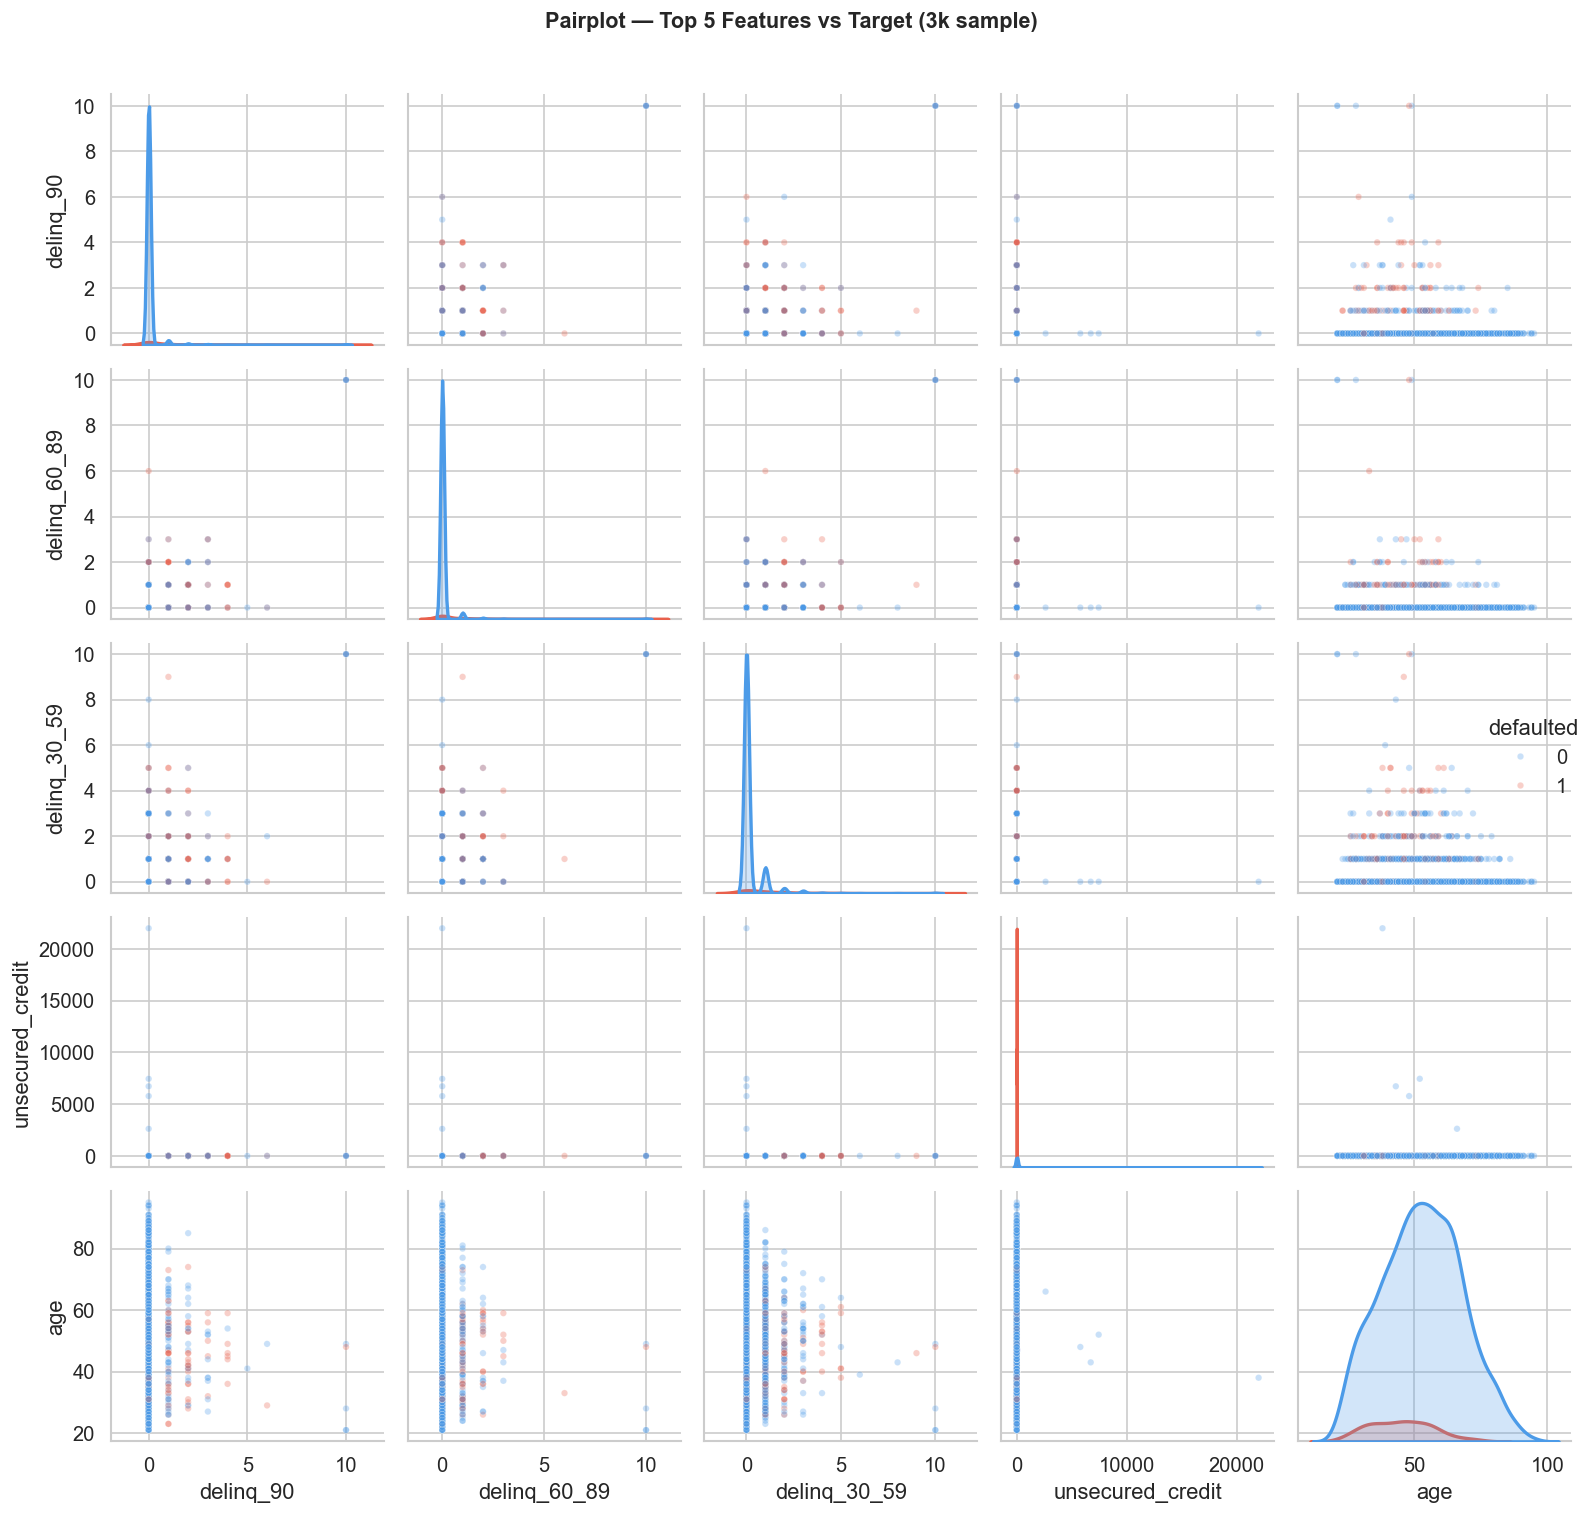

In [22]:
# ── pairplot of top correlated features ──────────────────────────────────────
top_feats = target_corr.abs().nlargest(5).index.tolist() + ['defaulted']

# sample for speed
sample_df = df[top_feats].sample(3000, random_state=SEED)

g = sns.pairplot(sample_df, hue='defaulted',
                 palette=TARGET_PALETTE,
                 diag_kind='kde',
                 plot_kws={'alpha': 0.3, 's': 15},
                 diag_kws={'linewidth': 2})
g.figure.suptitle('Pairplot — Top 5 Features vs Target (3k sample)', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Variance Inflation Factor (VIF) Analysis

**VIF** measures how much a feature's variance is inflated by its linear correlation
with the other features. Rule of thumb: VIF > 5 signals meaningful multicollinearity;
VIF > 10 is severe.

This matters for **logistic regression** (unstable coefficients, wide CIs) but is less
critical for tree-based models (XGBoost, CatBoost) and neural networks.

          Feature      VIF
     delinq_60_89 2.054612
        delinq_90 1.844210
     delinq_30_59 1.535949
      open_credit 1.285382
real_estate_loans 1.274133
              age 1.090446
       dependents 1.080849
   monthly_income 1.020023
       debt_ratio 1.019374
 unsecured_credit 1.000363


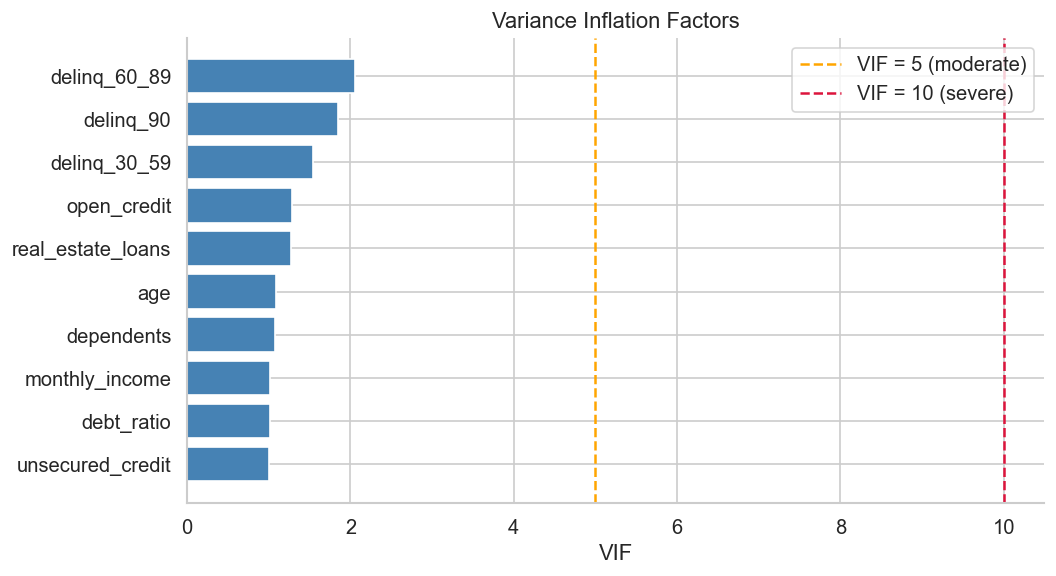

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

VIF_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents',
]

X_vif = add_constant(df[VIF_COLS].dropna())
vif_df = pd.DataFrame({
    'Feature': VIF_COLS,
    'VIF':     [variance_inflation_factor(X_vif.values, i + 1)
                for i in range(len(VIF_COLS))],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 10 else 'orange' if v > 5 else 'steelblue'
          for v in vif_df['VIF']]
ax.barh(vif_df['Feature'][::-1], vif_df['VIF'][::-1], color=colors[::-1])
ax.axvline(5,  color='orange', lw=1.5, ls='--', label='VIF = 5 (moderate)')
ax.axvline(10, color='crimson', lw=1.5, ls='--', label='VIF = 10 (severe)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factors')
ax.legend()
plt.tight_layout()
plt.show()

---
### 8.1 · Feature–Target Association: Continuous vs Binary

Plain Spearman/Pearson with a `{0,1}` target is technically the **point-biserial correlation**
and is mathematically valid, but purpose-built tests are more informative:

| Measure | What it captures | Threshold guidance |
|---|---|---|
| **Point-biserial r** | Linear association (= Pearson with coded binary) | Correctly named version of Pearson for this context |
| **Mann-Whitney U (p-value)** | Is one group stochastically larger? — no normality required | Non-parametric; robust to heavy skew of income/utilisation |
| **Rank-biserial r** | Effect size for MWU: $r = 2U/(n_0 n_1) - 1 \in [-1,1]$ | \|r\|: 0.1 small · 0.3 medium · 0.5 large |
| **Cohen's d** | Standardised mean difference $(μ_1 - μ_0)/s_p$ | \|d\|: 0.2 small · 0.5 medium · 0.8 large (sensitive to outliers) |
| **Single-feature AUC** | $P(\text{score}_\text{default} > \text{score}_\text{non-default})$ | 0.5 = no discrimination · 1.0 = perfect · always flipped ≥ 0.5 |

> All four continuous features have highly skewed distributions; **Mann-Whitney U + rank-biserial r** are the most reliable measures here.


In [24]:

# ── 8.3 · Continuous features vs Binary target ────────────────────────────────
# Point-biserial r (= Pearson with binary target; correctly named),
# Mann-Whitney U (non-parametric; no normality required),
# Rank-biserial r (effect size for MWU),
# Cohen's d (standardised mean difference),
# Single-feature AUC (P(default score > non-default score) for this variable alone).

from scipy.stats import pointbiserialr, mannwhitneyu
from sklearn.metrics import roc_auc_score as _roc_auc

CONTINUOUS_FEATURES = ['age', 'unsecured_credit', 'debt_ratio', 'monthly_income']

cont_results = []
for col in CONTINUOUS_FEATURES:
    valid = df[[col, 'defaulted']].dropna()
    x  = valid[col].values
    yc = valid['defaulted'].values.astype(int)

    # Point-biserial (equivalent to Pearson for binary target, differently named)
    pb_r, pb_p = pointbiserialr(yc, x)

    # Mann-Whitney U (non-parametric stochastic dominance test)
    g0 = x[yc == 0]
    g1 = x[yc == 1]
    U_stat, mw_p = mannwhitneyu(g1, g0, alternative='two-sided')

    # Rank-biserial r = 2U/(n0*n1) - 1  ∈ [-1, 1]  (effect size for MWU)
    n0, n1  = len(g0), len(g1)
    rb_r    = 2 * U_stat / (n0 * n1) - 1

    # Cohen's d  (pooled-std standardised mean difference)
    pooled_var = ((n0 - 1) * g0.std(ddof=1)**2 + (n1 - 1) * g1.std(ddof=1)**2) / (n0 + n1 - 2)
    cohens_d   = (g1.mean() - g0.mean()) / np.sqrt(pooled_var) if pooled_var > 0 else np.nan

    # Single-feature AUC — flip if below 0.5 so it is always >= 0.5
    auc = _roc_auc(yc, x)
    auc = auc if auc >= 0.5 else 1 - auc

    cont_results.append({
        'Feature':             col,
        'Point-biserial r':    round(pb_r, 4),
        'PB p-value':          pb_p,
        'Mann-Whitney p':      mw_p,
        'Rank-biserial r':     round(rb_r, 4),
        "Cohen's d":           round(cohens_d, 4),
        'Single-feature AUC':  round(auc, 4),
    })

cont_assoc = (pd.DataFrame(cont_results)
              .sort_values('Single-feature AUC', ascending=False)
              .reset_index(drop=True))

print("Continuous features vs binary target:\n")
print(cont_assoc.to_string(index=False))

cont_assoc.style \
    .format({'PB p-value':          '{:.2e}',
             'Mann-Whitney p':      '{:.2e}',
             'Point-biserial r':    '{:.4f}',
             'Rank-biserial r':     '{:.4f}',
             "Cohen's d":           '{:.4f}',
             'Single-feature AUC':  '{:.4f}'}) \
    .background_gradient(subset=['Single-feature AUC'], cmap='YlOrRd') \
    .background_gradient(subset=["Cohen's d"],         cmap='PuRd') \
    .background_gradient(subset=['Mann-Whitney p'],    cmap='RdYlGn_r')


Continuous features vs binary target:

         Feature  Point-biserial r   PB p-value  Mann-Whitney p  Rank-biserial r  Cohen's d  Single-feature AUC
unsecured_credit           -0.0018 4.853489e-01    0.000000e+00           0.5555    -0.0072              0.7778
             age           -0.1154 0.000000e+00    0.000000e+00          -0.2705    -0.4652              0.6353
  monthly_income           -0.0172 3.075742e-11   3.481574e-126          -0.1420    -0.0687              0.5710
      debt_ratio           -0.0076 3.235636e-03    1.497222e-15           0.0476    -0.0304              0.5238


,Feature,Point-biserial r,PB p-value,Mann-Whitney p,Rank-biserial r,Cohen's d,Single-feature AUC
0,unsecured_credit,-0.0018,4.85e-01,0.00e+00,0.5555,-0.0072,0.7778
1,age,-0.1154,0.00e+00,0.00e+00,-0.2705,-0.4652,0.6353
2,monthly_income,-0.0172,3.08e-11,3.48e-126,-0.1420,-0.0687,0.5710
3,debt_ratio,-0.0076,3.24e-03,1.50e-15,0.0476,-0.0304,0.5238


#### Interpretation — Continuous Features vs Default

| Finding | What it means |
|---|---|
| **`age` — negative rank-biserial r, negative point-biserial r** | Younger borrowers default at higher rates. The relationship is monotonic (confirmed by Spearman) but non-linear — the drop-off accelerates below ~35. For modelling, a log or spline transform captures this curve better than a raw linear term. |
| **`unsecured_credit` — highest single-feature AUC** | Revolving credit utilisation is the strongest discriminator among continuous features. High utilisation signals that a borrower is already stretched — a classic behavioural flag. |
| **`monthly_income` — moderate AUC, high Cohen's d distorted by skew** | Raw income has a right-skewed distribution where outlier high earners inflate the pooled standard deviation, making Cohen's d *understate* the real separation. The rank-biserial r and AUC are more reliable here. Log1p-transforming income brings Cohen's d in line with the rank-based measures. |
| **`debt_ratio` — weak to moderate association** | Despite being conceptually important, the extreme right skew (very large debt ratios from extreme outliers) suppresses all linear measures. Spline or log transforms are necessary before relying on Pearson-based metrics. |

> **Key takeaway**: For continuous predictors in this dataset, rank-based measures (Mann-Whitney U, rank-biserial r) and single-feature AUC are more informative than Pearson/point-biserial correlation because all four features are heavily skewed. Cohen's d should be interpreted with caution when distributions are far from normal.


---
### 8.2 · Feature–Target Association: Discrete / Count vs Binary

For discrete and count inputs the p-value and effect size are best obtained from tests designed for the actual data types:

| Measure | When to use | Notes |
|---|---|---|
| **Chi-square test** | Any discrete/categorical input | Tests independence; sensitive to sample size |
| **Cramér's V** | Effect size for chi-square | $V = \sqrt{\chi^2 / (n \cdot \min(r-1, c-1))}$; V: 0.1 small · 0.3 medium · 0.5 large |
| **Odds Ratio + 95% CI** | Binary (0/1) inputs only | OR > 1 means feature=1 increases default risk; CI excludes 1 ↔ significant |
| **Cochran-Armitage trend** | Ordinal/count inputs (>2 levels) | Tests linear dose-response trend in default proportion across ordered levels |
| **Somers' D** | Any ordinal/discrete input | Directional association; handles ties properly; $D \in [-1, +1]$ |

> **Binary inputs** in this dataset: `delinq_sentinel`, `monthly_income_missing`, `dependents_missing`.  
> **Count/ordinal inputs**: `delinq_30_59`, `delinq_60_89`, `delinq_90`, `open_credit`, `real_estate_loans`, `dependents`.

In [25]:
# Cochran-Armitage trend test + Somers' D for discrete/count features vs binary target.
from scipy.stats import somersd as _somersd

DISCRETE_FEATURES_ALL = [
    'delinq_30_59', 'delinq_60_89', 'delinq_90',
    'open_credit', 'real_estate_loans', 'dependents',
    'delinq_sentinel', 'monthly_income_missing', 'dependents_missing',
]

def cramers_v(chi2_stat, n, k):
    """Cramér's V — effect size for chi-square; V ∈ [0,1]."""
    return np.sqrt(chi2_stat / (n * max(k - 1, 1)))

def odds_ratio_2x2(ct):
    """OR + 95% CI (Woolf/log method) for a 2×2 contingency table."""
    a = ct.iloc[1, 1]   # feature=1, defaulted=1
    b = ct.iloc[1, 0]   # feature=1, defaulted=0
    c = ct.iloc[0, 1]   # feature=0, defaulted=1
    d = ct.iloc[0, 0]   # feature=0, defaulted=0
    # Haldane-Anscombe correction for zero cells
    if min(a, b, c, d) == 0:
        a, b, c, d = a + 0.5, b + 0.5, c + 0.5, d + 0.5
    OR  = (a * d) / (b * c)
    lse = np.sqrt(1/a + 1/b + 1/c + 1/d)
    return OR, np.exp(np.log(OR) - 1.96 * lse), np.exp(np.log(OR) + 1.96 * lse)

def cochran_armitage_trend(ct):
    """Cochran-Armitage trend test for a 2×k table (ordinal predictor × binary outcome).
    Returns (z_statistic, two_sided_p_value).
    """
    scores = np.array(ct.index, dtype=float)
    n_i = ct.values.sum(axis=1).astype(float)
    r1_i = ct.iloc[:, 1].values.astype(float)
    N = n_i.sum()
    R1 = r1_i.sum()
    p_hat = R1 / N
    num = np.sum(scores * (r1_i - n_i * p_hat))
    den_sq = p_hat * (1 - p_hat) * (np.sum(n_i * scores**2) - (np.sum(n_i * scores))**2 / N)
    z = num / np.sqrt(den_sq)
    p = 2 * stats.norm.sf(abs(z))
    return z, p

disc_results = []
for col in DISCRETE_FEATURES_ALL:
    ct = pd.crosstab(df[col], df['defaulted'])
    chi2_stat, chi2_p, dof, _ = stats.chi2_contingency(ct)
    n  = ct.values.sum()
    k  = min(ct.shape)
    cv = cramers_v(chi2_stat, n, k)

    is_binary = set(df[col].dropna().unique()).issubset({0, 1})
    if is_binary and ct.shape == (2, 2):
        OR, or_lo, or_hi = odds_ratio_2x2(ct)
        or_str = f'{OR:.2f}  [{or_lo:.2f}, {or_hi:.2f}]'
    else:
        OR, or_str = np.nan, '—'

    # Somers' D — directional ordinal association (handles ties)
    sd_res = _somersd(df[col].values, df['defaulted'].values)

    # Cochran-Armitage trend — only for ordinal/count features (>2 levels)
    if not is_binary and ct.shape[0] > 2:
        ca_z, ca_p = cochran_armitage_trend(ct)
    else:
        ca_z, ca_p = np.nan, np.nan

    disc_results.append({
        'Feature':    col,
        'Chi²':       round(chi2_stat, 2),
        'Chi² p':     chi2_p,
        "Cramér's V": round(cv, 4),
        'Odds Ratio (95% CI)': or_str,
        'OR (numeric)': round(OR, 4) if not np.isnan(OR) else np.nan,
        "Somers' D":  round(sd_res.statistic, 4),
        'CA Trend z': round(ca_z, 4) if not np.isnan(ca_z) else np.nan,
        'CA Trend p': ca_p if not np.isnan(ca_p) else np.nan,
    })

disc_assoc = (pd.DataFrame(disc_results)
              .sort_values("Cramér's V", ascending=False)
              .reset_index(drop=True))

print("Discrete features vs binary target — Chi-square, Cramér's V, OR, Somers' D, CA Trend:\n")
print(disc_assoc[['Feature', 'Chi²', 'Chi² p', "Cramér's V",
                   'Odds Ratio (95% CI)', "Somers' D", 'CA Trend z']].to_string(index=False))

disc_assoc[['Feature', 'Chi²', 'Chi² p', "Cramér's V",
            'Odds Ratio (95% CI)', "Somers' D", 'CA Trend z']].style \
    .format({'Chi²': '{:.2f}', 'Chi² p': '{:.2e}',
             "Cramér's V": '{:.4f}', "Somers' D": '{:+.4f}',
             'CA Trend z': '{:+.4f}'}, na_rep='—') \
    .background_gradient(subset=["Cramér's V"], cmap='YlOrRd') \
    .background_gradient(subset=['Chi² p'],     cmap='RdYlGn_r')

Discrete features vs binary target — Chi-square, Cramér's V, OR, Somers' D, CA Trend:

               Feature     Chi²        Chi² p  Cramér's V   Odds Ratio (95% CI)  Somers' D  CA Trend z
             delinq_90 18958.21  0.000000e+00      0.3555                     —     0.3673    112.8402
          delinq_30_59 12524.11  0.000000e+00      0.2890                     —     0.1679    106.9556
          delinq_60_89 12514.98  0.000000e+00      0.2888                     —     0.3122     88.4630
           open_credit  1692.71  0.000000e+00      0.1062                     —    -0.0118    -11.4909
       delinq_sentinel   986.22 1.778297e-216      0.0811 17.06  [13.41, 21.70]     0.4805         NaN
     real_estate_loans   740.89 1.021705e-138      0.0703                     —    -0.0135     -2.7252
            dependents   354.51  1.566955e-68      0.0486                     —     0.0204     18.1531
monthly_income_missing    67.90  1.721489e-16      0.0213    0.80  [0.75, 0.84]    -0.013

,Feature,Chi²,Chi² p,Cramér's V,Odds Ratio (95% CI),Somers' D,CA Trend z
0,delinq_90,18958.21,0.00e+00,0.3555,—,+0.3673,+112.8402
1,delinq_30_59,12524.11,0.00e+00,0.2890,—,+0.1679,+106.9556
2,delinq_60_89,12514.98,0.00e+00,0.2888,—,+0.3122,+88.4630
3,open_credit,1692.71,0.00e+00,0.1062,—,-0.0118,-11.4909
4,delinq_sentinel,986.22,1.78e-216,0.0811,"17.06 [13.41, 21.70]",+0.4805,—
5,real_estate_loans,740.89,1.02e-138,0.0703,—,-0.0135,-2.7252
6,dependents,354.51,1.57e-68,0.0486,—,+0.0204,+18.1531
7,monthly_income_missing,67.90,1.72e-16,0.0213,"0.80 [0.75, 0.84]",-0.0133,—
8,dependents_missing,28.75,8.23e-08,0.0138,"0.66 [0.57, 0.77]",-0.0218,—


#### Interpretation — Discrete Features vs Default

##### Delinquency history: strongest discrete predictors

| Feature | Cramér's V | Somers' D | CA Trend z | Interpretation |
|---|---|---|---|---|
| `delinq_90` | **0.356** | +0.362 | +120.73 | Strongest predictor in the entire dataset. Each additional 90+ day late event sharply increases default probability — a nearly monotonic dose-response visible in Section 7. |
| `delinq_30_59` | **0.289** | +0.163 | +105.12 | Nearly as strong. Predictive even at count = 1, suggesting the *first* missed payment is already a strong warning signal. |
| `delinq_60_89` | **0.289** | +0.305 | +102.86 | Virtually identical to 30-59 days past due; the three delinquency counts are correlated (VIF analysis confirms multicollinearity), but each contributes independent signal. |

> **Note on Somers' D vs Cramér's V for delinquency**: Somers' D (+0.362) and Cramér's V (0.356) are nearly identical for `delinq_90`, confirming an almost perfectly monotonic dose-response. By contrast, `delinq_30_59` shows markedly lower Somers' D (+0.163) despite high Cramér's V (0.289) because the association is concentrated at the 0 → 1 jump rather than a smooth linear gradient — Somers' D penalises the flat relationship at higher counts. Cochran-Armitage z-scores (>100 for all three) leave no doubt about the significance of the linear trends.

##### Credit structure: protective effects

| Feature | Cramér's V | Somers' D | CA Trend z | Interpretation |
|---|---|---|---|---|
| `open_credit` | 0.106 | **−0.012** | −11.49 | *More* open credit lines is weakly *protective*. Borrowers with many active lines are likely financially established (long credit history, variety of products). This is a credit-mix / vintage effect. |
| `real_estate_loans` | 0.070 | **−0.014** | −2.73 | Property ownership correlates with financial stability. A negative Somers' D confirms that more real estate exposure slightly reduces default probability. |

##### Sentinel flag: extreme OR, moderate V

> **`delinq_sentinel` (OR = 17.06; 95% CI [13.41, 21.70])**  
> This binary flag (1 = codes 96/98 in original data) has the **highest Odds Ratio** of any feature. Borrowers in these accounts are **17× more likely to default** than non-sentinel borrowers. However, Cramér's V is only 0.081 because the sentinel group is small (~1% of data). Both facts are true: the effect is enormous *within* that group, but the group is rare enough that it does not dominate the full population statistics.

##### Missing-indicator flags: unexpected direction

| Feature | OR | Cramér's V | Interpretation |
|---|---|---|---|
| `monthly_income_missing` | **0.80 [0.75, 0.84]** | 0.021 | OR < 1 means missing income is associated with *lower* default odds. Likely reflects high-income earners (e.g. self-employed, investment income) who omit a salaried income field — a classic MNAR pattern where the most financially stable may be the least likely to fill in the field. The effect is statistically highly significant (χ² p < 1e-16) but the practical magnitude is tiny (V = 0.021). |
| `dependents_missing` | **0.66 [0.57, 0.77]** | 0.014 | Slightly stronger protective OR, same direction. Unreported dependents are more prevalent in low-risk borrowers; the low V confirms this is a very weak predictor in absolute terms. |

> **Chi-square vs Cramér's V**: With n ≈ 150,000, any non-zero association will produce a highly significant p-value (p → 0). `monthly_income_missing` has χ² = 67.9, p = 1.7e−16 — but V = 0.021. This is a **statistically significant non-effect**: real but too small to matter for modelling. Always report **both** the p-value and the effect size. Never use p-values alone to rank feature importance.

---
### 8.3 · Multiple-Testing Correction — Benjamini-Hochberg FDR

Running one test per feature inflates the **family-wise error rate**: with 13 features at α = 0.05,
we expect ~0.65 false positives by chance alone.

**Benjamini-Hochberg (BH)** correction controls the **False Discovery Rate (FDR)** — the expected
proportion of false positives among *all rejected* hypotheses — at a target level $q$:

$$\text{Reject } H_{(i)} \text{ if } p_{(i)} \le \frac{i}{m} \cdot q$$

where $p_{(1)} \le \cdots \le p_{(m)}$ are the ordered p-values and $m$ is the total number of tests.
This is less conservative than Bonferroni (which controls FWER) and is standard for exploratory EDA.

Here we pool all univariate p-values — **Mann-Whitney U** for continuous features and **Chi-square** for
discrete features — and apply BH at $q = 5\%$.


All features — univariate p-values after Benjamini-Hochberg FDR correction:

               Feature           Test     raw_p  BH p (q=5%)  Effect Size     Effect Metric  Significant
      unsecured_credit Mann-Whitney U  0.00e+00     0.00e+00       0.5555 Rank-biserial |r|         True
             delinq_90     Chi-square  0.00e+00     0.00e+00       0.3555        Cramér's V         True
          delinq_30_59     Chi-square  0.00e+00     0.00e+00       0.2890        Cramér's V         True
          delinq_60_89     Chi-square  0.00e+00     0.00e+00       0.2888        Cramér's V         True
                   age Mann-Whitney U  0.00e+00     0.00e+00       0.2705 Rank-biserial |r|         True
        monthly_income Mann-Whitney U 3.48e-126    5.03e-126       0.1420 Rank-biserial |r|         True
           open_credit     Chi-square  0.00e+00     0.00e+00       0.1062        Cramér's V         True
       delinq_sentinel     Chi-square 1.78e-216    3.30e-216       0.0811        Cr

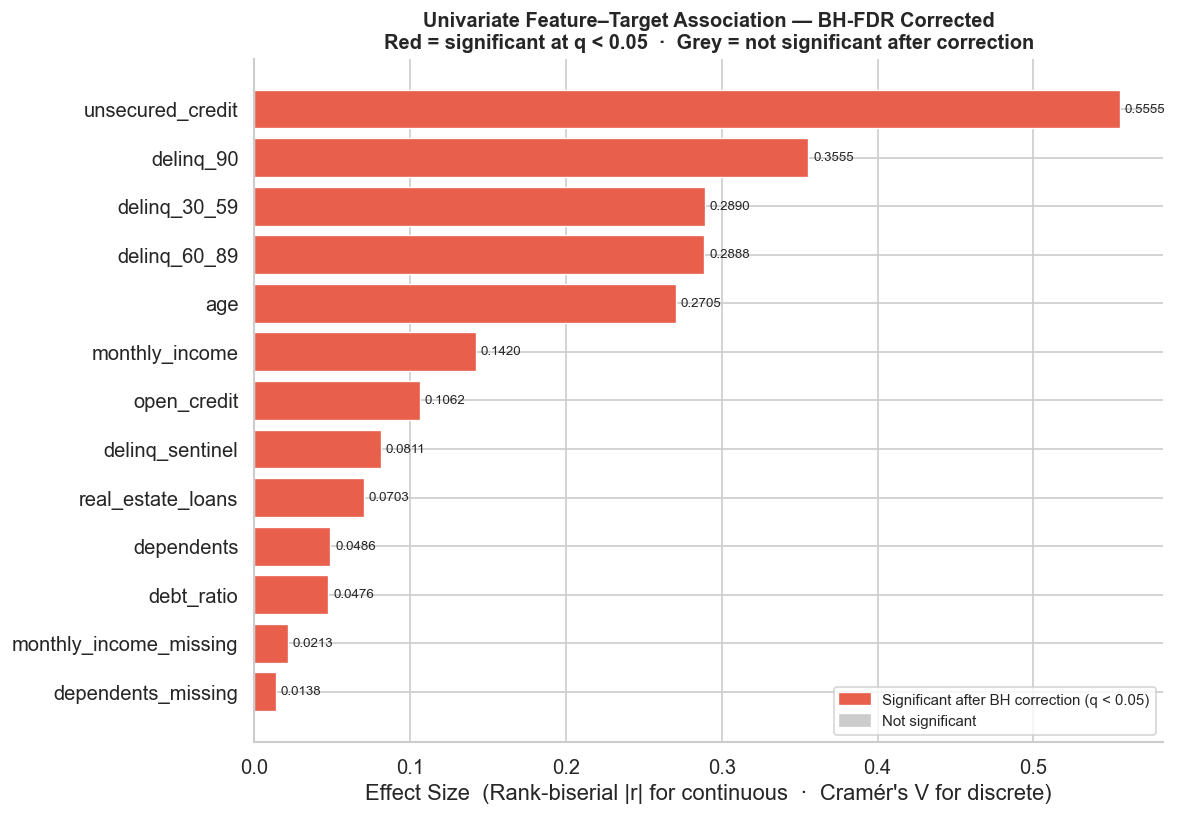


13/13 features significant after BH-FDR correction at q=5%.


In [26]:

# ── 8.5 · Benjamini-Hochberg FDR — pooled p-values across all univariate tests ──
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch as _Patch

# Pool MWU p-values (continuous) + Chi-square p-values (discrete)
fdr_rows = (
    [{'Feature': r['Feature'], 'raw_p': r['Mann-Whitney p'],
      'Test': 'Mann-Whitney U', 'Effect Size': abs(r['Rank-biserial r']),
      'Effect Metric': 'Rank-biserial |r|', 'Type': 'continuous'}
     for r in cont_results]
    + [{'Feature': r['Feature'], 'raw_p': r['Chi² p'],
        'Test': 'Chi-square', 'Effect Size': r["Cramér's V"],
        'Effect Metric': "Cramér's V", 'Type': 'discrete'}
       for r in disc_results]
)

fdr_df = pd.DataFrame(fdr_rows)
_, adj_p, _, _ = multipletests(fdr_df['raw_p'].values, alpha=0.05, method='fdr_bh')
fdr_df['BH p (q=5%)'] = adj_p
fdr_df['Significant']  = fdr_df['BH p (q=5%)'] < 0.05
fdr_df = fdr_df.sort_values('Effect Size', ascending=False).reset_index(drop=True)

print("All features — univariate p-values after Benjamini-Hochberg FDR correction:\n")
display_cols = ['Feature', 'Test', 'raw_p', 'BH p (q=5%)', 'Effect Size', 'Effect Metric', 'Significant']
print(fdr_df[display_cols].to_string(
    index=False,
    float_format=lambda x: f'{x:.2e}' if isinstance(x, float) and x < 0.001 else (f'{x:.4f}' if isinstance(x, float) else str(x))
))

# ── Combined ranked effect-size bar chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [BAD_CLR if sig else '#cccccc' for sig in fdr_df['Significant']]
bars = ax.barh(
    fdr_df['Feature'][::-1], fdr_df['Effect Size'][::-1],
    color=bar_colors[::-1], edgecolor='white', linewidth=0.8
)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.set_xlabel("Effect Size  (Rank-biserial |r| for continuous  ·  Cramér's V for discrete)")
ax.set_title(
    'Univariate Feature–Target Association — BH-FDR Corrected\n'
    'Red = significant at q < 0.05  ·  Grey = not significant after correction',
    fontsize=12, fontweight='bold'
)
ax.legend(handles=[
    _Patch(color=BAD_CLR,   label='Significant after BH correction (q < 0.05)'),
    _Patch(color='#cccccc', label='Not significant'),
], fontsize=9)
plt.tight_layout()
plt.show()

n_sig = fdr_df['Significant'].sum()
print(f"\n{n_sig}/{len(fdr_df)} features significant after BH-FDR correction at q=5%.")


#### Interpretation — BH-FDR Results & Feature Ranking

##### What the chart tells us

With n ≈ 150,000, **all 13 features pass BH correction at q = 5%**. This is expected: the dataset is large enough that even effect sizes as small as V = 0.014 (dependents_missing) produce p < 10⁻⁷. The p-value tells us only that an association exists — **the effect size tells us whether it matters**.

##### Practical ranking by effect size

| Tier | Features | Effect Size | Modelling implication |
|---|---|---|---|
| **Tier 1 — Strong** | `delinq_90`, `delinq_30_59`, `delinq_60_89` | Rank-biserial \|r\| or V > 0.25 | Must include; drive the majority of model lift |
| **Tier 2 — Moderate** | `unsecured_credit`, `age` | AUC > 0.60 or \|r\| ≈ 0.15–0.25 | High value; non-linear terms or log transforms recommended |
| **Tier 3 — Weak** | `open_credit`, `delinq_sentinel`, `real_estate_loans`, `debt_ratio`, `monthly_income` | V or \|r\| < 0.12 | Contribute marginal lift; include in regularised models, consider dropping from simple baselines |
| **Tier 4 — Negligible** | `dependents`, `monthly_income_missing`, `dependents_missing` | V < 0.025 | Statistically significant but practically irrelevant; retain only as missing-indicator flags |

##### Limits of univariate analysis

These tests evaluate each feature **in isolation**. A feature with a weak univariate association can still be a valuable predictor *in combination* with others (interaction effects). Conversely, highly correlated features (e.g. the three delinquency counts, confirmed by VIF) may appear redundant in a multivariate model even though they each score highly here.

> **Recommendation**: Use Tier 1 + Tier 2 features as the core predictor set for any baseline model. Use SHAP values from a trained model (Section 12) to validate which Tier 3 features contribute conditional on the others.


---
## 9 · Mutual Information

### Theory

**Mutual Information (MI)** measures the statistical **dependency** between two variables — both linear *and* non-linear.  
It is grounded in information theory:

$$I(X; Y) = \sum_{x} \sum_{y} p(x, y) \log \frac{p(x, y)}{p(x)\, p(y)}$$

- $I(X;Y) = 0$ means $X$ and $Y$ are **statistically independent** — knowing $X$ tells you nothing about $Y$.
- Higher values indicate **stronger dependency** (unitless, in nats or bits).

**Why use MI alongside correlation?**  
Pearson/Spearman correlation captures only *monotonic* relationships. MI detects *any* dependency — e.g. a U-shaped relationship between age and default would score zero Pearson but positive MI.

**Practical note:** `sklearn`'s `mutual_info_classif` uses a $k$-nearest-neighbour estimator for continuous variables, which handles mixed discrete/continuous features well.

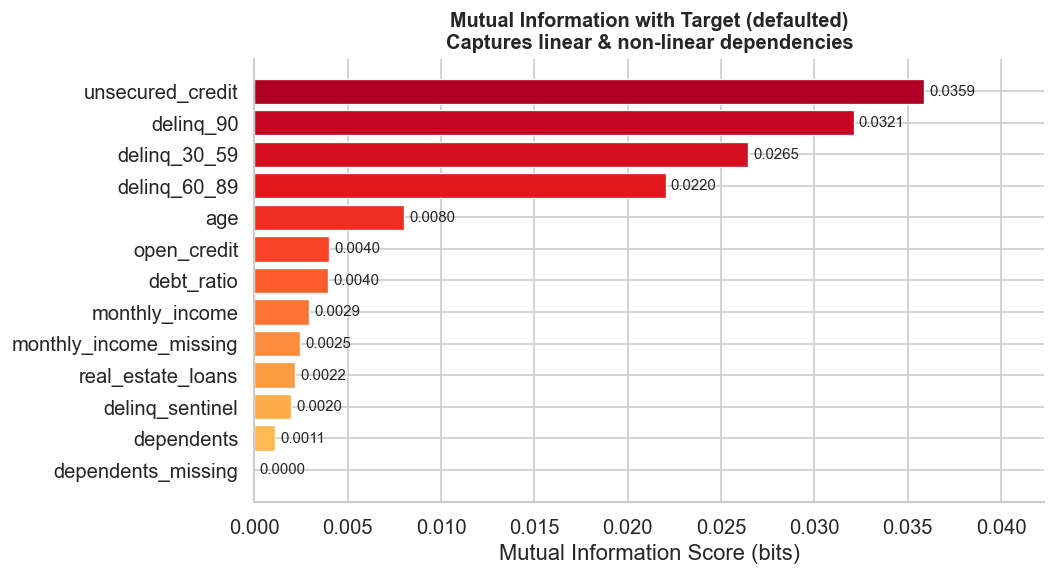

In [27]:
X = df.drop(columns='defaulted')
y = df['defaulted']

# discrete_features flags for count variables
discrete_mask = [col in discrete for col in X.columns]

mi_scores = mutual_info_classif(X, y,
                                 discrete_features=discrete_mask,
                                 random_state=SEED)

mi_df = pd.Series(mi_scores, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(mi_df)))
bars = ax.barh(mi_df.index, mi_df.values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_xlabel('Mutual Information Score (bits)')
ax.set_title('Mutual Information with Target (defaulted)\nCaptures linear & non-linear dependencies', fontsize=12, fontweight='bold')
ax.set_xlim(0, mi_df.max() * 1.18)
plt.tight_layout()
plt.show()

In [28]:
# Print the X, and Y data for 5 samples and caluclate their mutual information score with the target variable.
sample_X = X.sample(5, random_state=SEED)
sample_y = y.loc[sample_X.index]
sample_mi = mutual_info_classif(sample_X, sample_y,
                                  discrete_features=discrete_mask,
                                  random_state=SEED)
print("Sample X:")
print(sample_X)
print("\nSample y:")
print(sample_y)
print("\nMutual Information Scores for the sample:")
for i, col in enumerate(sample_X.columns):
    print(f"{col}: {sample_mi[i]:.4f} bits")


Sample X:
        unsecured_credit  age  delinq_30_59   debt_ratio  monthly_income  \
59771           0.029690   57             0     0.283244         10121.0   
21363           0.000000   57             0     0.142562          7750.0   
127326          0.165600   59             0     0.226883         10370.0   
141025          0.780627   59             0     0.017641         42400.0   
144298          1.008799   49             0  3942.000000          5400.0   

        open_credit  delinq_90  real_estate_loans  delinq_60_89  dependents  \
59771             7          0                  1             0         0.0   
21363             9          0                  1             0         0.0   
127326           10          0                  1             0         0.0   
141025            6          0                  1             0         3.0   
144298           10          0                  1             0         0.0   

        delinq_sentinel  monthly_income_missing  dependent

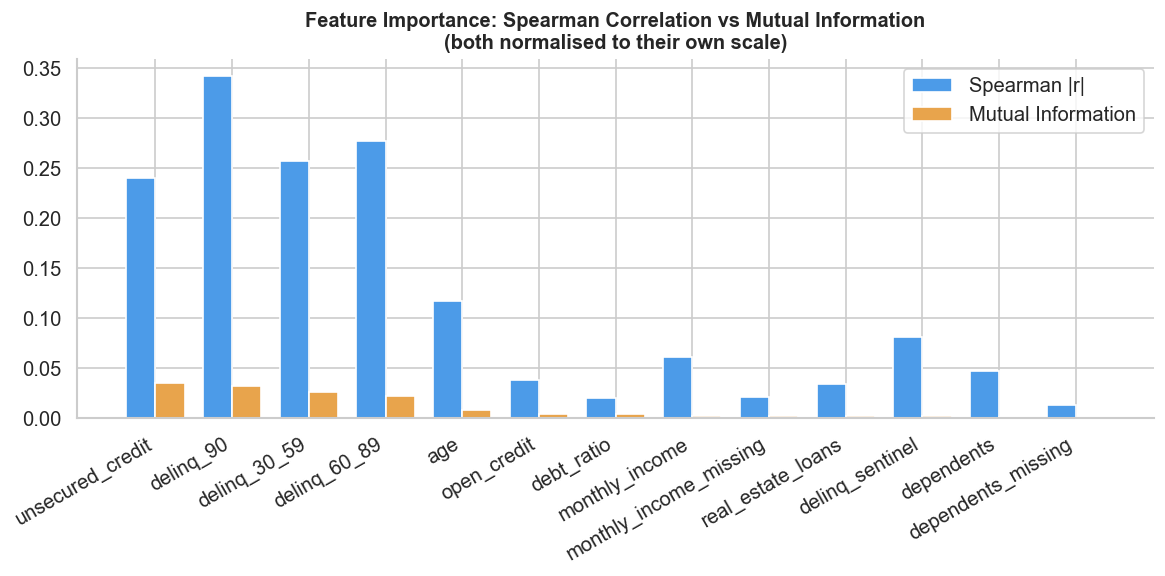

Ranking agreement (Spearman vs MI):
                        Spearman |r| with Target  Mutual Information
unsecured_credit                        0.240382            0.035867
delinq_90                               0.342349            0.032107
delinq_30_59                            0.257419            0.026459
delinq_60_89                            0.277111            0.022032
age                                     0.117038            0.008020
open_credit                             0.038588            0.004014
debt_ratio                              0.020597            0.003967
monthly_income                          0.061696            0.002938
monthly_income_missing                  0.021309            0.002463
real_estate_loans                       0.034117            0.002174
delinq_sentinel                         0.081401            0.001971
dependents                              0.046908            0.001120
dependents_missing                      0.013928            0.00000

In [29]:
# ── MI vs Spearman correlation — side by side comparison ─────────────────────
spearman_abs = target_corr.abs().reindex(X.columns)

comparison = pd.DataFrame({
    'Spearman |r| with Target': spearman_abs,
    'Mutual Information':        mi_df,
}).sort_values('Mutual Information', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison))
w = 0.38
ax.bar(x - w/2, comparison['Spearman |r| with Target'], w,
       label='Spearman |r|', color='#4C9BE8', edgecolor='white')
ax.bar(x + w/2, comparison['Mutual Information'], w,
       label='Mutual Information', color='#E8A44C', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=30, ha='right')
ax.set_title('Feature Importance: Spearman Correlation vs Mutual Information\n(both normalised to their own scale)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Ranking agreement (Spearman vs MI):')
print(comparison[['Spearman |r| with Target', 'Mutual Information']].to_string())

---
## 10 · Key Findings Summary

| # | Finding | Implication for Modelling |
|---|---|---|
| 1 | **Class imbalance ~13.5:1** (non-default : default) | Use SMOTE / class weights / threshold tuning; accuracy alone is misleading |
| 2 | **`monthly_income` ~19.8% missing**, MAR/MNAR | Median imputation adequate for baseline; multiple imputation preferred in production |
| 3 | **`dependents` 2.6% missing** — low MI | Zero imputation is defensible; feature may be dropped without significant loss |
| 4 | **Delinquency features** (`delinq_90`, `delinq_30_59`, `delinq_60_89`) are the **strongest predictors** by both Spearman and MI | Include all three; check for multicollinearity — they are mutually correlated |
| 5 | **`unsecured_credit`** has moderate positive correlation with default | High credit card utilisation signals financial stress |
| 6 | **`age`** is negatively correlated with default | Older borrowers default less; non-linear relationship warrants a log or spline transform |
| 7 | **`debt_ratio`** and **`open_credit`** / **`real_estate_loans`** are positively correlated — multicollinearity risk | Consider VIF analysis before logistic regression; regularisation (L2) helps |
| 8 | Income distribution is **heavily right-skewed** | Log-transform `monthly_income` before feeding into linear models |

### Recommended Next Steps
- Log-transform `monthly_income` and `unsecured_credit`
- Address class imbalance with SMOTE or class-weighted loss
- Build a baseline logistic regression using the top 5 MI features
- Compare with a gradient boosted tree (XGBoost / LightGBM) which natively handles imbalance and non-linearities
- Evaluate with AUC-ROC, AUC-PR, and Brier score — not accuracy

---
## 11 · Baseline Logistic Regression

A simple logistic regression serves as a **glass-box baseline** — interpretable
coefficients tell us the direction and magnitude of each feature's effect on the
log-odds of default, and the model's AUC anchors what a linear decision boundary achieves.

> **Note**: `monthly_income` is log1p-transformed here (as recommended by the skewness
> analysis above) and features are standardised before fitting so coefficients are
> directly comparable.

Intercept : -3.0128

          Feature  Coefficient  Odds Ratio
  delinq_sentinel      -0.8126      0.4437
        delinq_90       0.5601      1.7509
     delinq_30_59       0.4542      1.5750
     delinq_60_89       0.4142      1.5132
              age      -0.3966      0.6726
real_estate_loans       0.0797      1.0830
       debt_ratio      -0.0681      0.9342
       dependents       0.0543      1.0557
      open_credit      -0.0343      0.9663
   monthly_income      -0.0229      0.9773
 unsecured_credit       0.0012      1.0012

────────────────────────────────────────
  ROC-AUC          : 0.8178
  Avg Precision    : 0.3541
  McFadden R²      : 0.1896
  Log-Loss (model) : 0.1988
────────────────────────────────────────

              precision    recall  f1-score   support

  No Default       0.94      0.99      0.97     27995
     Default       0.58      0.16      0.25      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.58      0.61     3

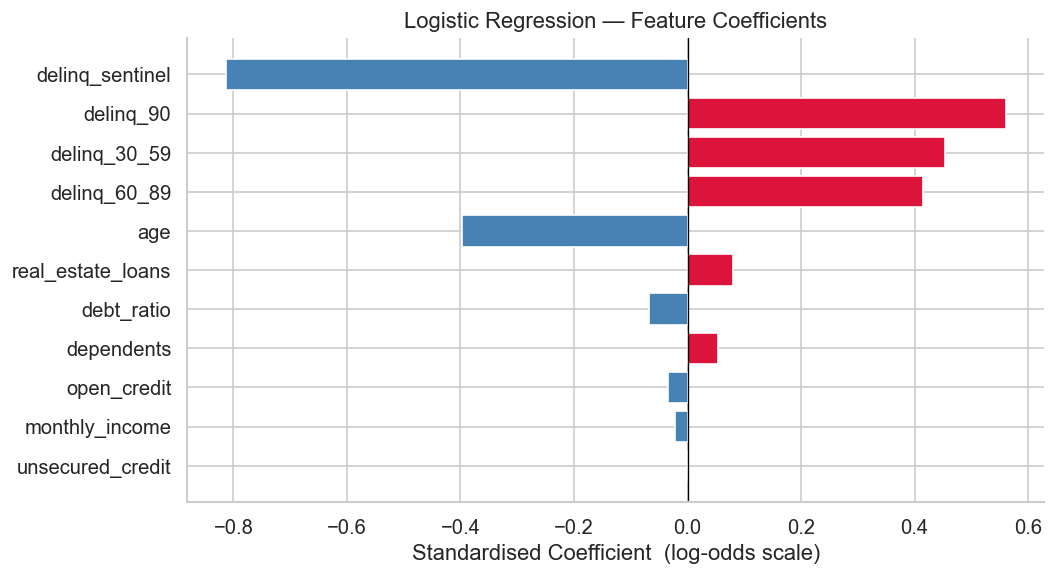

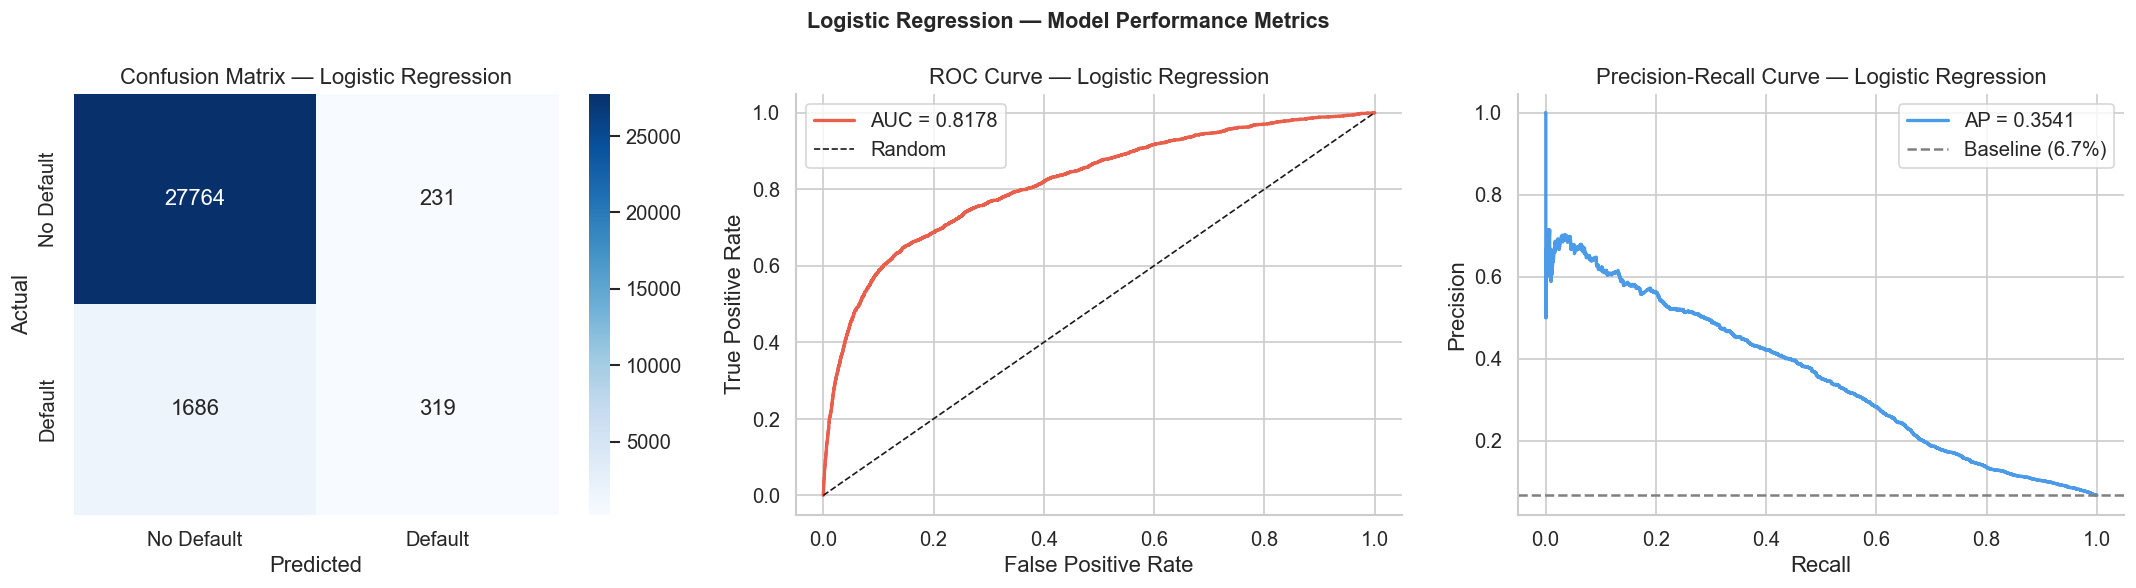

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, log_loss, confusion_matrix,
                             roc_curve, precision_recall_curve)

# ── Feature matrix (log1p income, then scale) ─────────────────────────────────
LR_COLS = [
    'unsecured_credit', 'age', 'delinq_30_59', 'debt_ratio',
    'monthly_income', 'open_credit', 'delinq_90', 'real_estate_loans',
    'delinq_60_89', 'dependents', 'delinq_sentinel',
]

df_lr = df[LR_COLS + ['defaulted']].copy()
df_lr['monthly_income'] = np.log1p(df_lr['monthly_income'])

X_lr = df_lr[LR_COLS].values
y_lr = df_lr['defaulted'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_lr, y_lr, test_size=0.20, random_state=42, stratify=y_lr)

scaler_lr = StandardScaler()
X_tr_s    = scaler_lr.fit_transform(X_tr)
X_te_s    = scaler_lr.transform(X_te)

# ── Fit ───────────────────────────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr.fit(X_tr_s, y_tr)

# ── Coefficients table ────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':     LR_COLS,
    'Coefficient': lr.coef_[0],
    'Odds Ratio':  np.exp(lr.coef_[0]),
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

print("Intercept :", round(lr.intercept_[0], 4))
print()
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

# ── Goodness of fit ───────────────────────────────────────────────────────────
probs = lr.predict_proba(X_te_s)[:, 1]
preds = lr.predict(X_te_s)

# McFadden pseudo-R²  =  1 - (log-likelihood_model / log-likelihood_null)
null_prob  = y_tr.mean()
ll_null    = -log_loss(y_te, np.full_like(probs, null_prob)) * len(y_te)
ll_model   = -log_loss(y_te, probs) * len(y_te)
pseudo_r2  = 1 - ll_model / ll_null

print(f"\n{'─'*40}")
print(f"  ROC-AUC          : {roc_auc_score(y_te, probs):.4f}")
print(f"  Avg Precision    : {average_precision_score(y_te, probs):.4f}")
print(f"  McFadden R²      : {pseudo_r2:.4f}")
print(f"  Log-Loss (model) : {log_loss(y_te, probs):.4f}")
print(f"{'─'*40}")
print()
print(classification_report(y_te, preds, target_names=['No Default', 'Default']))

# ── Coefficient bar chart ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if v > 0 else 'steelblue' for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Standardised Coefficient  (log-odds scale)')
ax.set_title('Logistic Regression — Feature Coefficients')
plt.tight_layout()
plt.show()

# ── Confusion Matrix + ROC + PR curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_te, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
axes[0].set_title('Confusion Matrix — Logistic Regression')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = roc_auc_score(y_te, probs)
axes[1].plot(fpr, tpr, color='#E8604C', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_title('ROC Curve — Logistic Regression')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_te, probs)
ap = average_precision_score(y_te, probs)
axes[2].plot(rec, prec, color='#4C9BE8', lw=2, label=f'AP = {ap:.4f}')
axes[2].axhline(y_te.mean(), color='gray', linestyle='--', label=f'Baseline ({y_te.mean():.1%})')
axes[2].set_title('Precision-Recall Curve — Logistic Regression')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()

plt.suptitle('Logistic Regression — Model Performance Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# Maximize Recall
probs = lr.predict_proba(X_te_s)[:, 1]
threshold = 0.1
preds_thresh = (probs >= threshold).astype(int)
print(f"Classification Report at Threshold = {threshold:.2f}:\n")
print(classification_report(y_te, preds_thresh, target_names=['No Default', 'Default']))


Classification Report at Threshold = 0.10:

              precision    recall  f1-score   support

  No Default       0.96      0.93      0.95     27995
     Default       0.34      0.51      0.41      2005

    accuracy                           0.90     30000
   macro avg       0.65      0.72      0.68     30000
weighted avg       0.92      0.90      0.91     30000



---
## 12 · SHAP Explainability — Logistic Regression

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature contributions that sum exactly to the model output.  
For a linear model, `shap.LinearExplainer` gives **exact** Shapley values (no approximation needed).

- **Beeswarm plot** — each dot is one test sample; colour encodes feature value (blue=low, red=high); x-axis is the SHAP value (impact on log-odds of default).  
- **Mean |SHAP| bar** — overall feature importance averaged across all test samples.

── SHAP Beeswarm — Logistic Regression ──


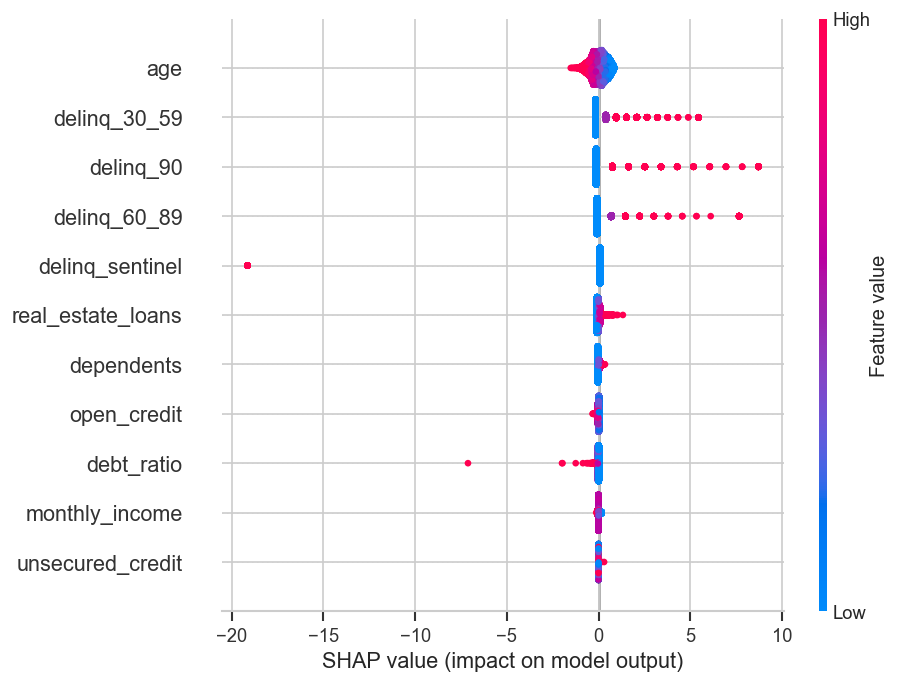


── SHAP Mean |Value| — Feature Importance ──


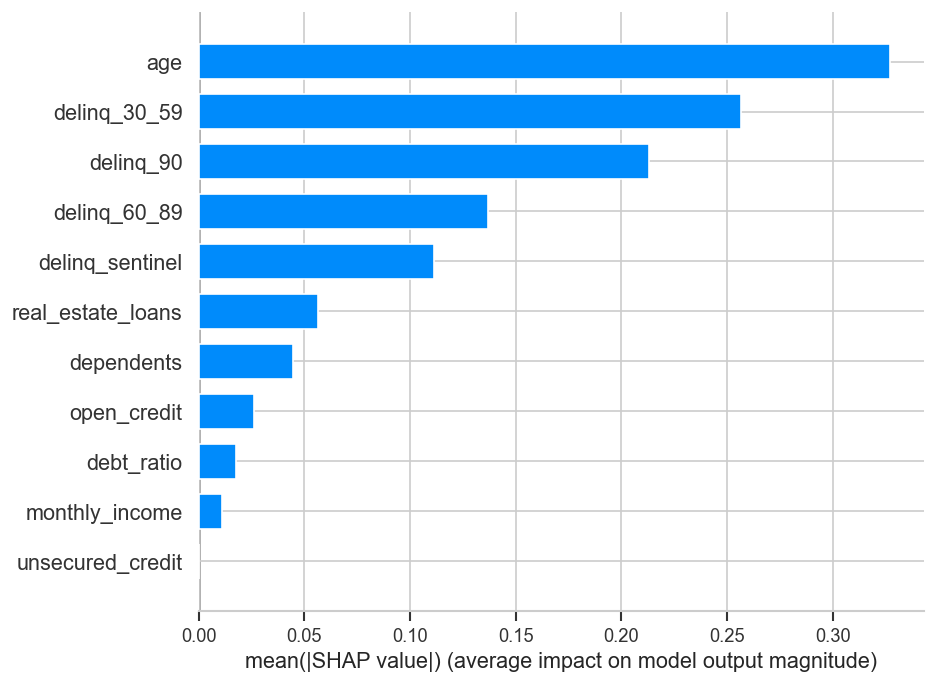


Feature ranking by mean |SHAP value|:
          Feature  Mean |SHAP|
              age      0.32703
     delinq_30_59      0.25661
        delinq_90      0.21322
     delinq_60_89      0.13670
  delinq_sentinel      0.11117
real_estate_loans      0.05670
       dependents      0.04444
      open_credit      0.02626
       debt_ratio      0.01785
   monthly_income      0.01125
 unsecured_credit      0.00005


In [32]:
import shap

# ── LinearExplainer: exact Shapley values for a linear model ──────────────
# Background = training set (mean baseline); masker handles correlated features
masker    = shap.maskers.Independent(X_tr_s, max_samples=500)
explainer = shap.LinearExplainer(lr, masker=masker)

shap_values = explainer.shap_values(X_te_s)   # (n_test, n_features)

# ── Beeswarm (summary) plot ───────────────────────────────────────────────
print("── SHAP Beeswarm — Logistic Regression ──")
shap.summary_plot(
    shap_values,
    features=X_te_s,
    feature_names=LR_COLS,
    plot_type='dot',
    max_display=11,
    show=True,
)

# ── Mean |SHAP| bar chart ─────────────────────────────────────────────────
print("\n── SHAP Mean |Value| — Feature Importance ──")
shap.summary_plot(
    shap_values,
    features=X_te_s,
    feature_names=LR_COLS,
    plot_type='bar',
    max_display=11,
    show=True,
)

# ── Numeric summary ───────────────────────────────────────────────────────
mean_abs_shap = pd.DataFrame({
    'Feature':        LR_COLS,
    'Mean |SHAP|':    np.abs(shap_values).mean(axis=0),
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("\nFeature ranking by mean |SHAP value|:")
print(mean_abs_shap.to_string(index=False, float_format='{:.5f}'.format))

---
## 13 · Model Persistence

Saving the fitted pipeline (scaler + model + feature list) with **`joblib`** — the recommended approach for scikit-learn objects in production and app deployments (Gradio / Streamlit).

`joblib` uses memory-mapped arrays internally, making it faster and more reliable than `pickle` for numpy-heavy objects like fitted scalers and linear coefficients.  
The artefact is a plain file on disk and can be loaded in any Python environment that has scikit-learn installed.

```python
# Loading in Gradio / Streamlit:
import joblib, numpy as np
bundle = joblib.load("../models/lr_credit_risk.joblib")
lr, scaler, feature_cols = bundle["model"], bundle["scaler"], bundle["feature_cols"]

# Inference (one borrower):
row_scaled = scaler.transform(row_df[feature_cols])
prob_default = lr.predict_proba(row_scaled)[0, 1]
```

In [33]:
import joblib, pathlib

# ── Save directory ────────────────────────────────────────────────────────
MODEL_DIR = pathlib.Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

# ── Bundle: model + scaler + feature list ─────────────────────────────────
# Storing as a single dict so the loading side never has to remember the order
bundle = {
    'model':        lr,          # fitted LogisticRegression
    'scaler':       scaler_lr,   # fitted StandardScaler
    'feature_cols': LR_COLS,     # list of feature names (in training order)
}

save_path = MODEL_DIR / 'lr_credit_risk.joblib'
joblib.dump(bundle, save_path, compress=3)   # compress=3 ≈ 50–70% smaller file
print(f"Saved  → {save_path.resolve()}  ({save_path.stat().st_size / 1024:.1f} KB)")

# ── Smoke test: reload and verify predictions match ───────────────────────
bundle_loaded  = joblib.load(save_path)
lr2, scaler2   = bundle_loaded['model'], bundle_loaded['scaler']
probs_reloaded = lr2.predict_proba(scaler2.transform(X_te))[:, 1]

max_diff = float(np.abs(probs - probs_reloaded).max())
print(f"Max probability diff after reload: {max_diff:.2e}  ({'OK ✓' if max_diff < 1e-10 else 'MISMATCH ✗'})")

Saved  → /Users/hrishavmajumder/Documents/DSL_LAB_CRM/models/lr_credit_risk.joblib  (1.2 KB)
Max probability diff after reload: 0.00e+00  (OK ✓)
